In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="20" color="red">ch12.데이터시각화</font>

In [134]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
#패키지 import
import matplotlib.pyplot as plt
import seaborn as sns

# 한글설정(win/MacOS)
plt.rcParams['font.family'] = 'BMJUA_ttf.ttf'
plt.rcParams['axes.unicode_minus']=False

# warning(경고) 안보이게
import warnings
warnings.filterwarnings(action='ignore') # 경고 메시지 안보이게
# warnings.filterwarnings(action='default') # 경고 메시지 다 보이게
# import seaborn as sns

# 2절. seaborn
- matplotlip기반으로 만든 고수준 그래픽 라이브러리
    * 공식 api 사이트 : https://seaborn.pydata.org/api.html
- Seaborn으로 그래프를 그리기 위해서 다음의 단계를 따릅니다.
    1) 데이터 준비
    2) 미적 속성 설정
    3) 함수를 이용해서 그래프 그리기(관계형-수치형,범주형,쌍관계,밀도,회귀,다중그래프...)4
        - 그래프 커스토마이징
    4) 그래프 출력(show),저장(savefig)

## 2.1 데이터 준비하기
- iris,titanic

In [11]:
iris = sns.load_dataset('iris')

In [4]:
titanic = sns.load_dataset('titanic')
# Survived : 생존 여부 (0 = 사망, 1 = 생존)
# Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
# Sex : 성별
# Age : 나이
# SibSp : 함께 탑승한 자녀 / 배우자 의 수
# Parch : 함께 탑승한 부모님 / 아이들 의 수
# Ticket : 티켓 번호
# Fare : 탑승 요금
# Cabin : 수하물 번호
# Boat : 탈출한 보트가 있다면 boat 번호
# Embarked : 선착장 (C = Cherbourg, Q = Queenstown, S = Southampton)
# Pclass : 승객 클래스(1 = 1등석; 2 = 2등석; 3 = 3등석)

# name 이름
# sex  성(male=남성, female=여성)
# age  나이
# sibsp 함께 승선한 형제, 자매, 배우자 수
# parch  함께 승선한 부모 자식 수
# ticket  티켓 번호
# fare  티켓 요금 (영국 파운드)
# cabin  객실 번호
# embarked 승선한 항구 (C = Cherbourg; Q = Queenstown; S = Southampton)
# boat  침몰시 탑승한 구명보트 번호
# body  사망자인 경우 지정된 번호
# home.dest  고향/목적지
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 2.2 미적속성설정(style,context,palette,figsize...)
### 1) 그래프 스타일 지정
- 미적 속성 설정 후, 한글설정을 다시 실행
- plt.rc('font',family='Malgun Gothic')# 윈도우즈  
- plt.rc('axes',unicode=minus=False)
- 범례(교안20p) : https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

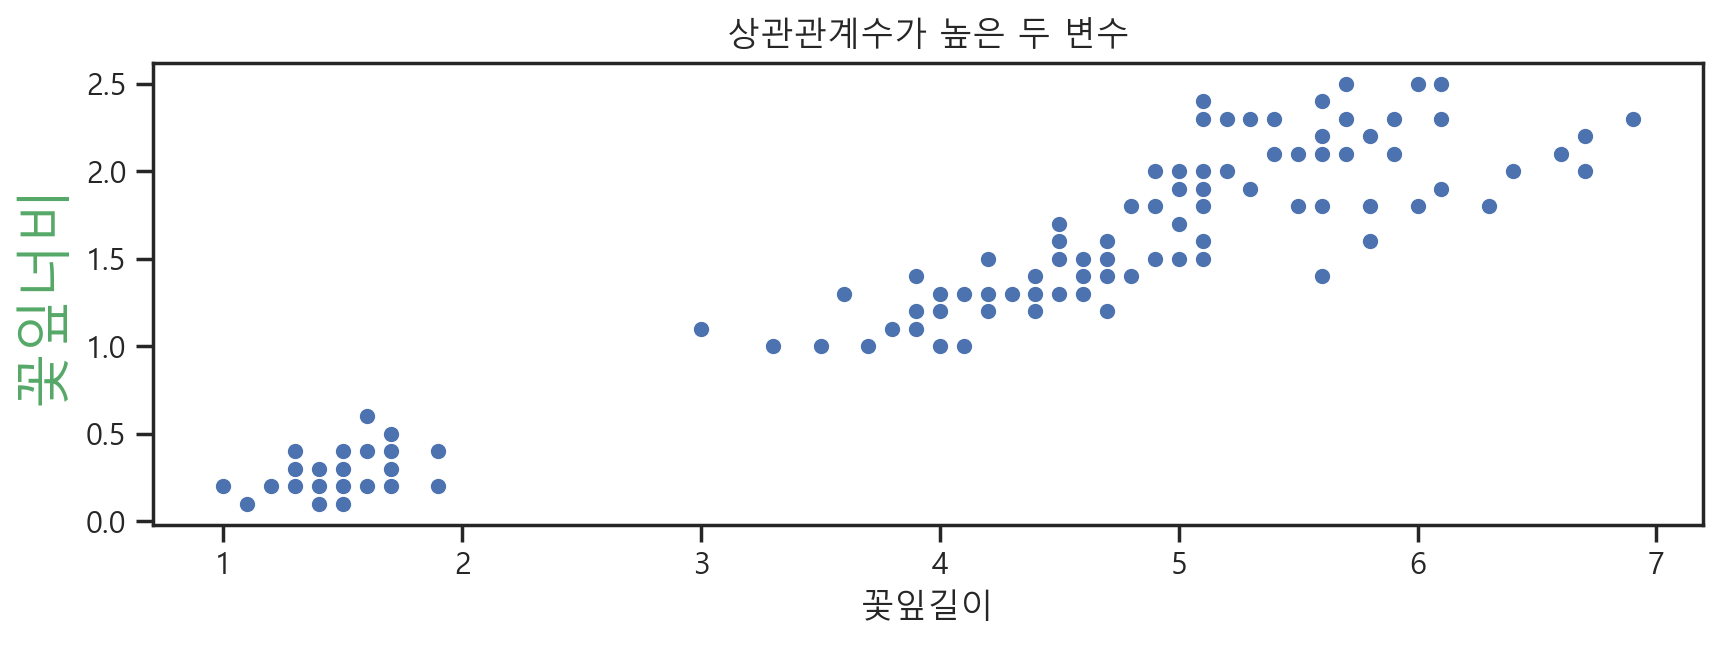

In [36]:
plt.rcParams['figure.figsize']=(10,3)
sns.set(style='ticks') #darkgrid, whitegrid, dark, white, ticks
# sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

ax=sns.scatterplot(data=iris, x='petal_length',y='petal_width')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(title = '상관관계수가 높은 두 변수',
      xlabel = '꽃잎길이')
ax.set_ylabel('꽃잎너비',fontsize=20,color='g')
plt.show()


### 2) 컨텍스트 지정(배율)

Text(0.5, 1.0, '상관관계가 높은 변수')

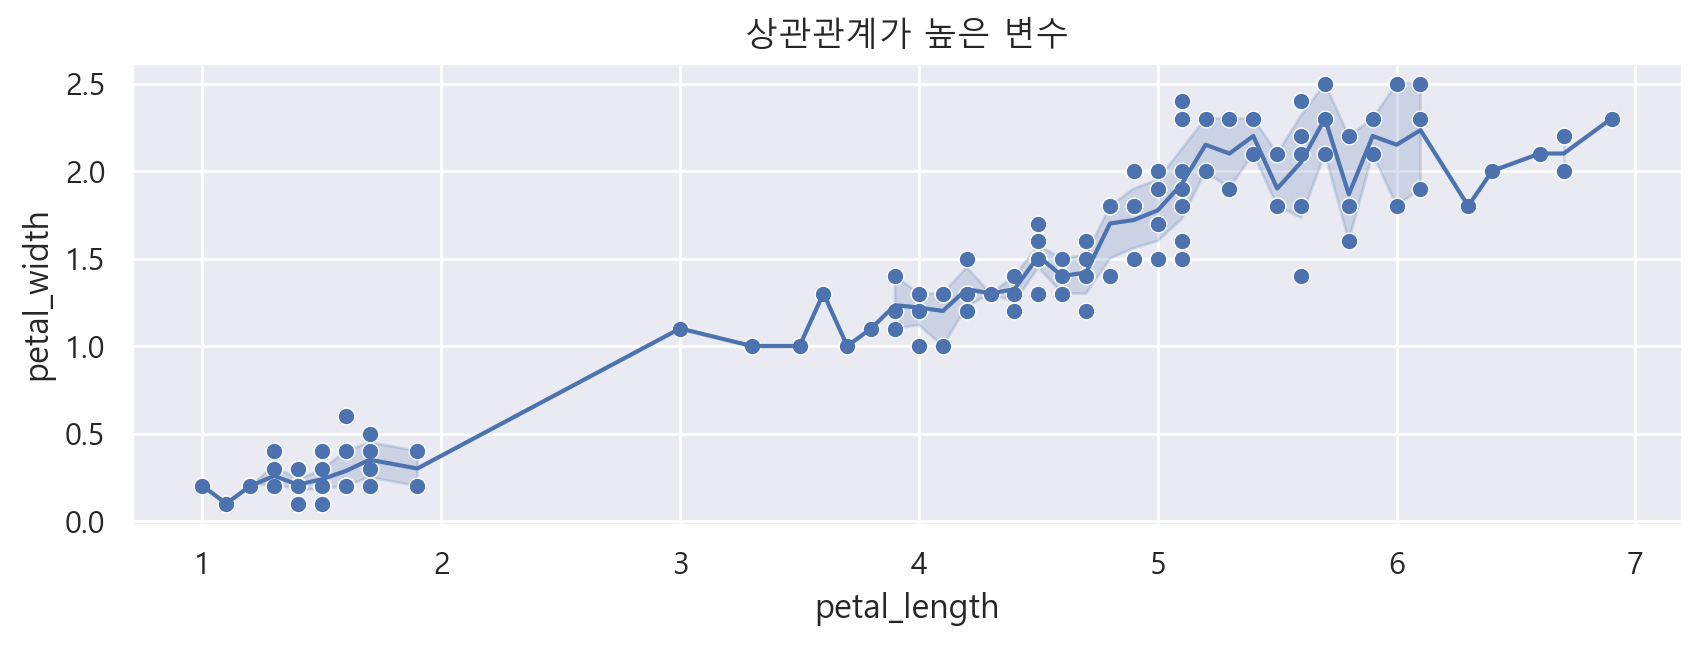

In [16]:
sns.set(context='notebook')#기본값 notebook(1,0),paper(0,0), talk(1,3), poster(1,8)
# sns.set_context('notebook')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
sns.lineplot(data=iris, x='petal_length',y='petal_width')
sns.scatterplot(data=iris,x='petal_length',y='petal_width')
plt.title('상관관계가 높은 변수')

### 3) 컬러 팔레트
- https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette
- https://matplotlib.org/stable/users/explain/colors/colormaps.html
- https://seaborn.pydata.org/tutorial/color_palettes.html

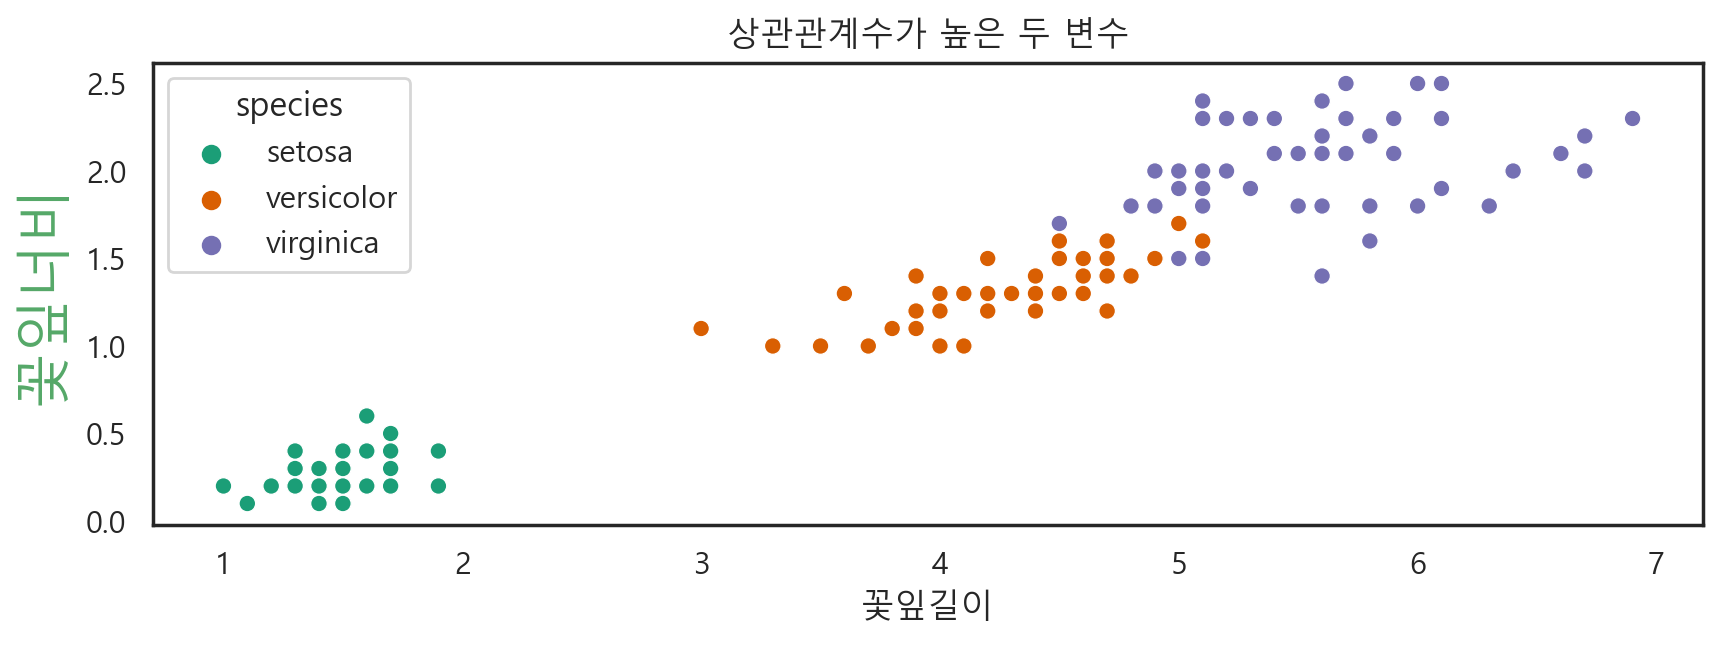

In [37]:
sns.set(palette='Pastel1',style='white',context='notebook')#기본 미적 속성 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
ax=sns.scatterplot(data=iris, x='petal_length',y='petal_width',hue='species',palette='Dark2')

ax.set(title = '상관관계수가 높은 두 변수',
      xlabel = '꽃잎길이')
ax.set_ylabel('꽃잎너비',fontsize=20,color='g')
plt.show()


In [2]:
# 시각화한 그래프를 저장할 해상도 높이기
%config InlineBackend.figure_format = 'retina'
#패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
#미적 속성 셋팅
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize':(12,3)})
#한글설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False


In [3]:
iris=sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')

## 2.3 Seaborn 함수로 그래프 그리기
### 1)관계형 그래프
    - scatterplot,lineplot,replot(서브플롯 제공)

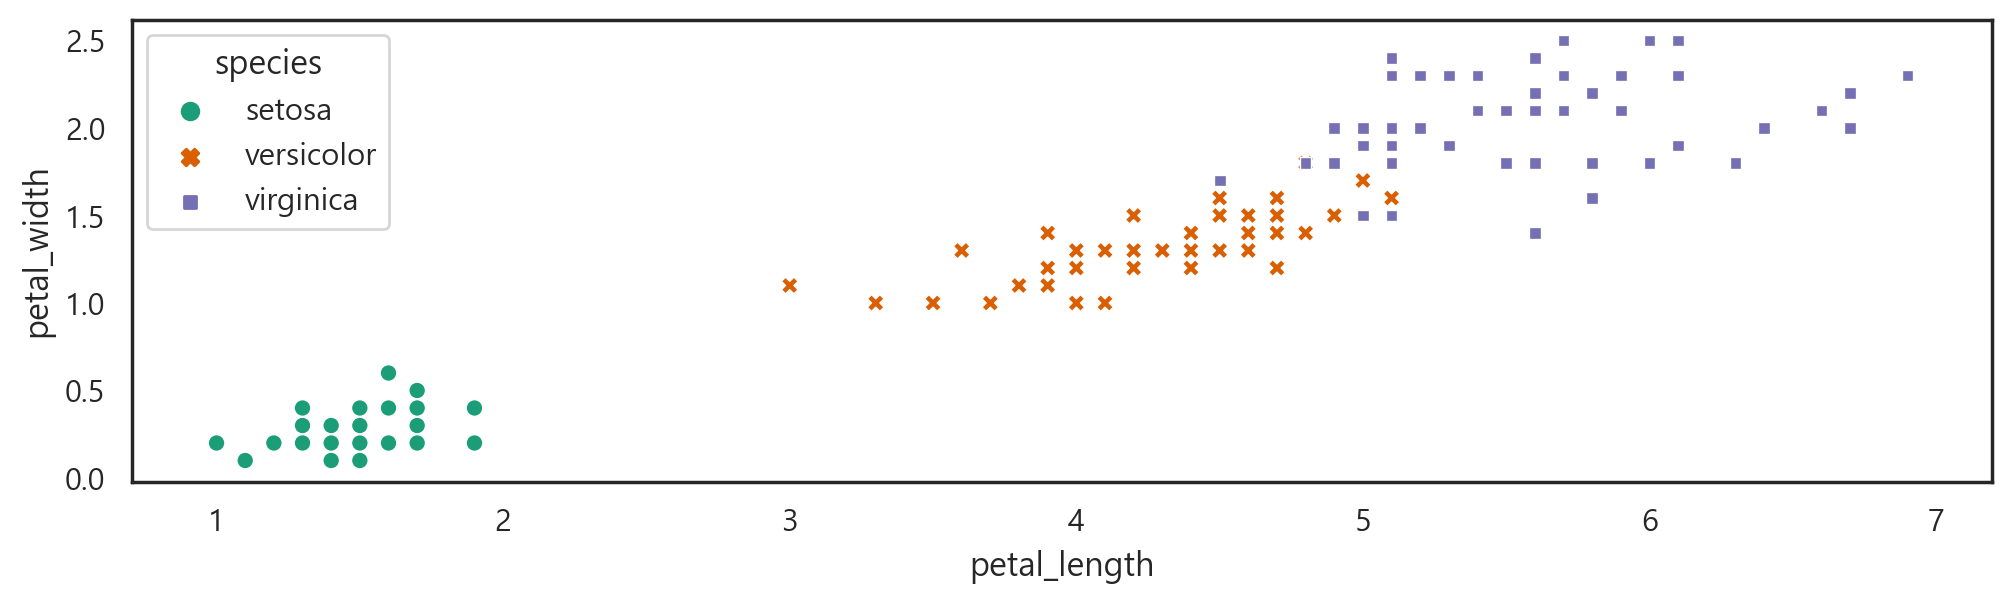

In [4]:
# 종별 다른색상과 다른 스타일의 scatterplt
sns.scatterplot(data=iris, x='petal_length',y='petal_width',hue='species',palette='Dark2',
               style='species')
# sns.scatterplot(x=iris.petal_length, y=iris.petal_width, hue=iris.species, palette='Set1',
#                style=iris.species)
plt.show()

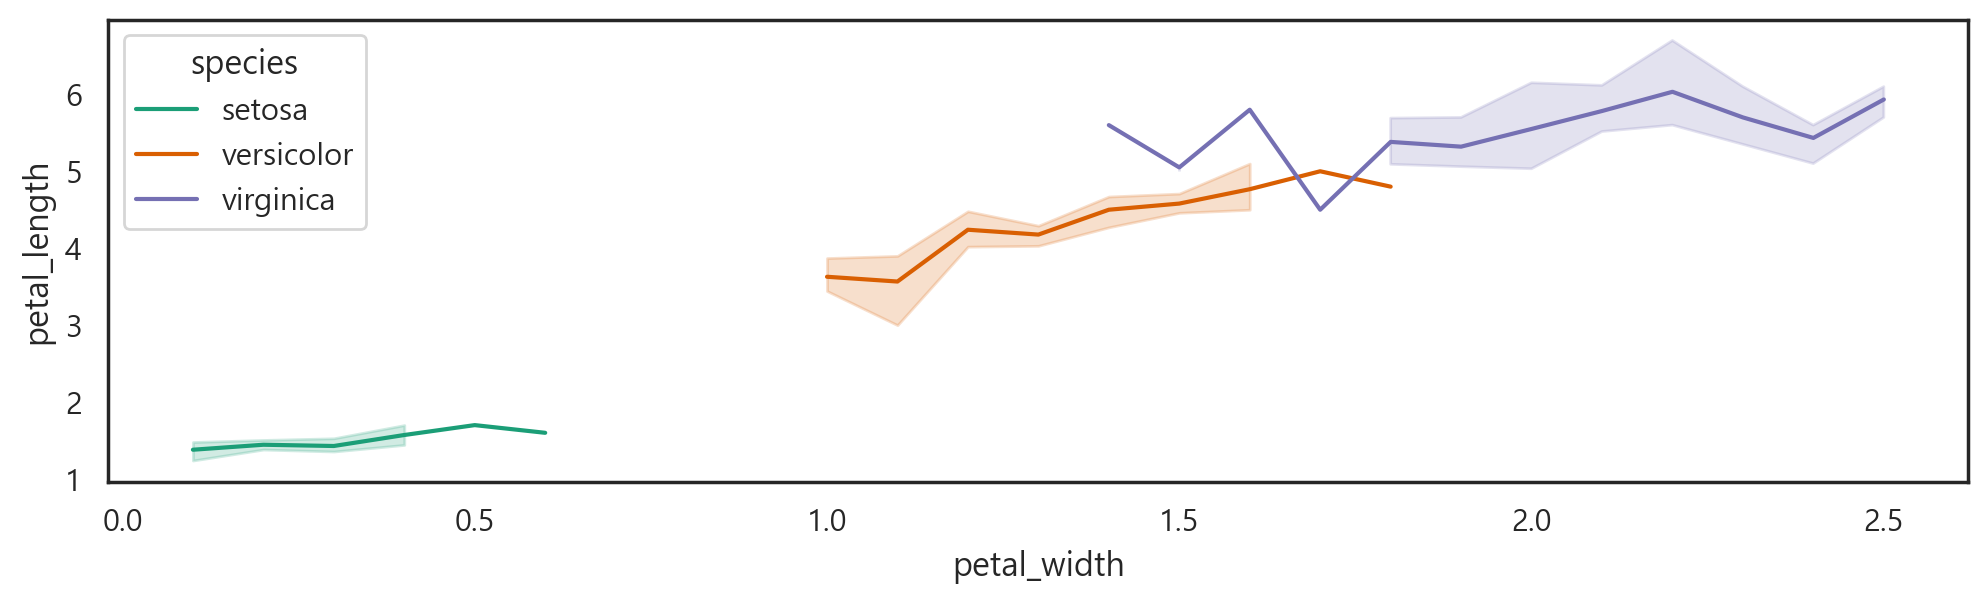

In [5]:
# 종별 다른 색상과 다른 스타일의 lineplot
sns.lineplot(data=iris,x='petal_width',y='petal_length',
             hue='species',palette='Dark2')
plt.show()

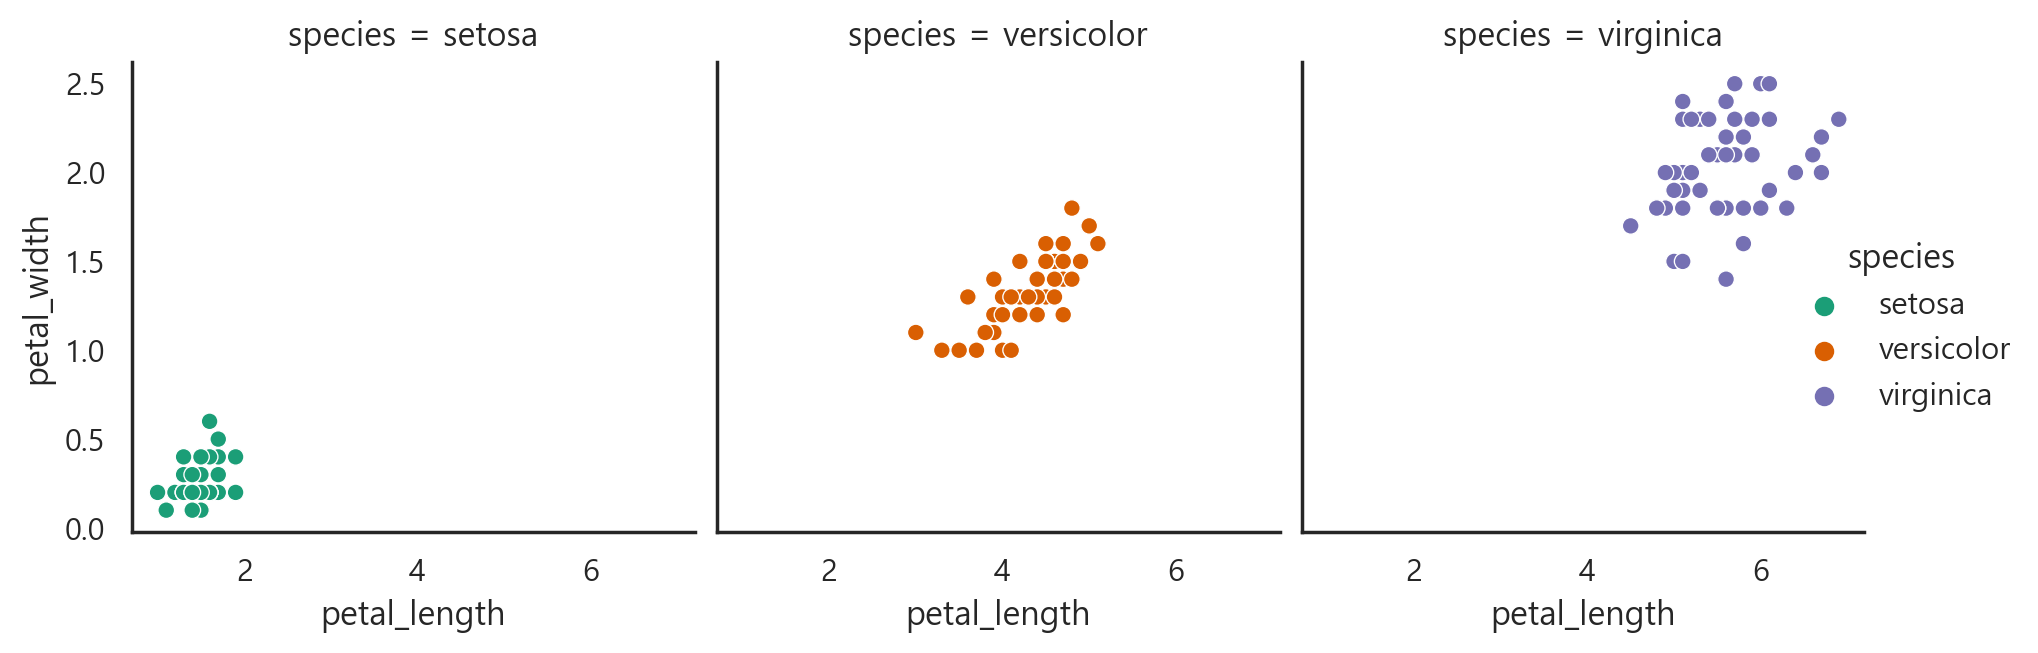

In [6]:
# 종별 lineflot을 서브플롯으로 =>replot(관계형 그래프에서 서브플롯을 그리는 함수)
g=sns.relplot(data=iris, x='petal_length',y='petal_width',hue='species',
           # 기본값은 kind='scatter',
              col='species', #col 단위로 서브플롯 표현
              #col_wrap=2  #한줄에 표현될 서브플롯 수
#               facet_kws={'sharey': False, 'sharex':False}# 축공유 여부
                       ) 
g.fig.set_size_inches(10,3)
plt.show()

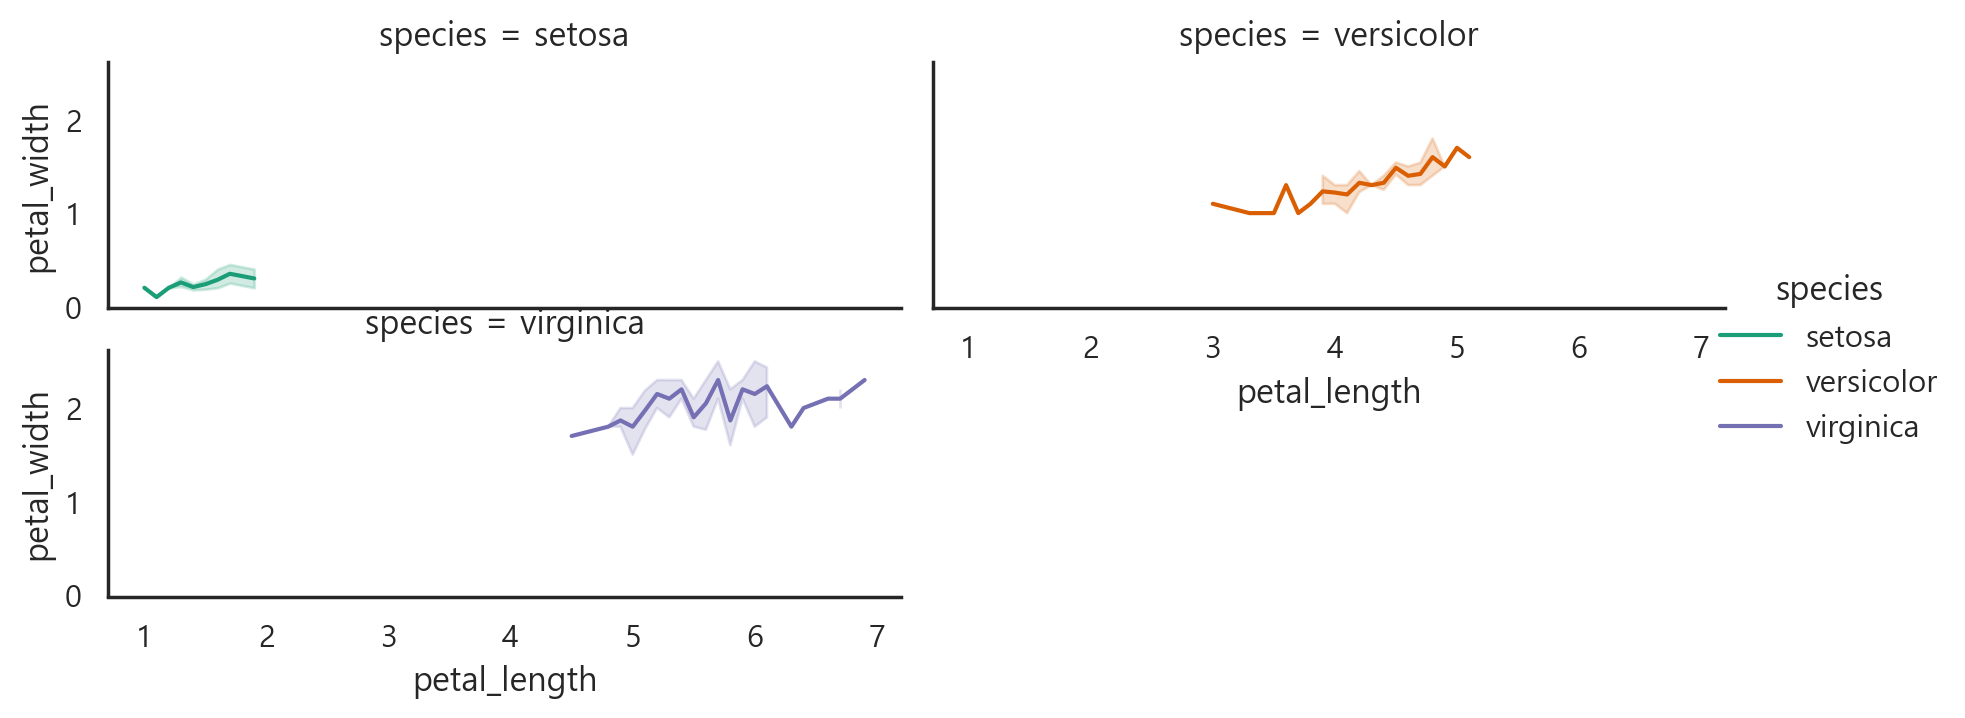

In [7]:
# 종별 lineflot을 서브플롯으로 =>replot(관계형 그래프에서 서브플롯을 그리는 함수)
g=sns.relplot(data=iris, 
              x='petal_length',
              y='petal_width',
              hue='species',
              kind='line',
              col='species',#col 단위로 서브플롯 표현
              col_wrap=2  #한줄에 표현될 서브플롯 수
#               facet_kws={'sharey': False, 'sharex':False}# 축공유 여부
                       ) 
g.fig.set_size_inches(10,3)
plt.show()

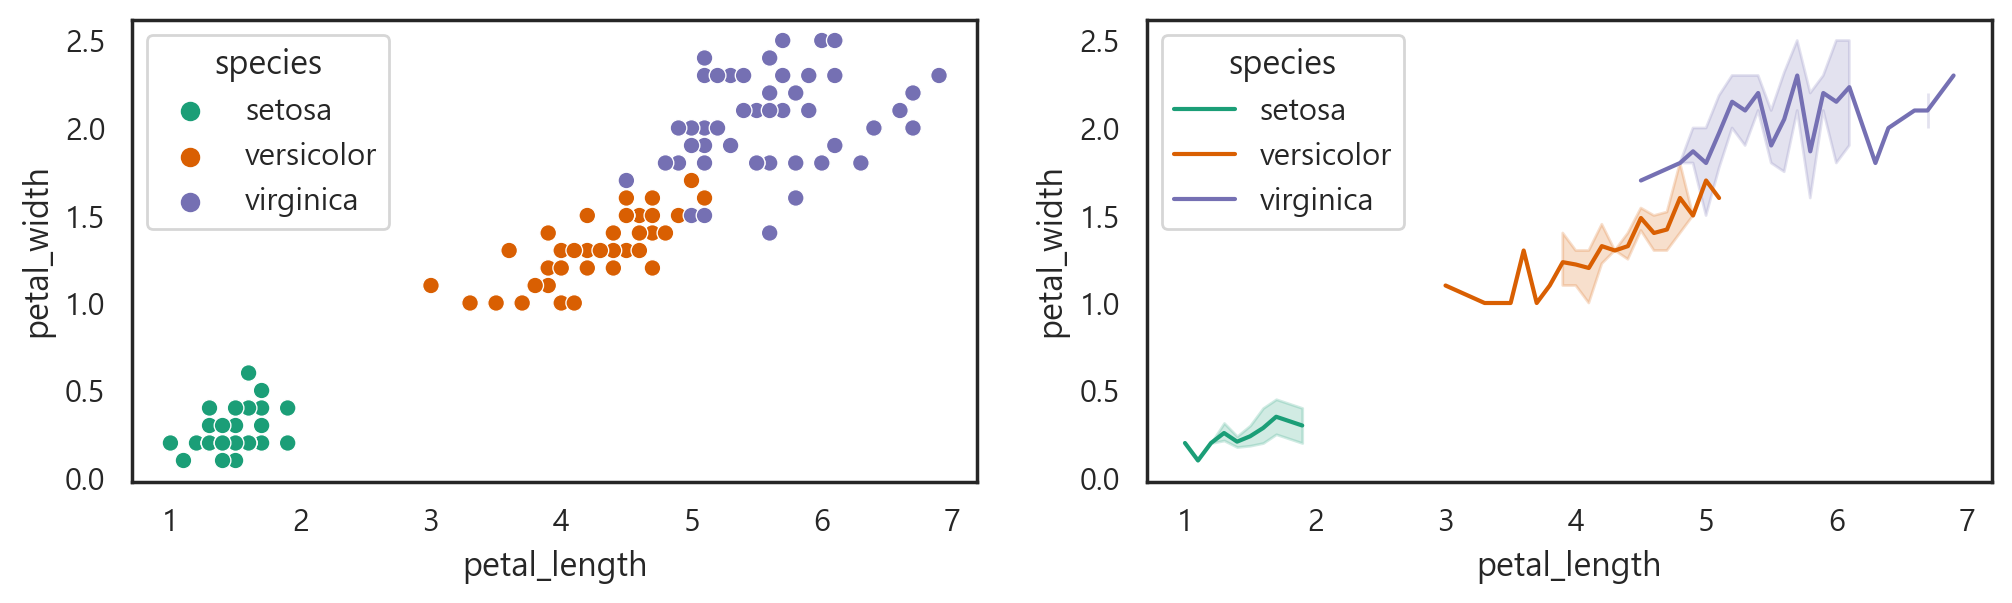

In [8]:
# 서브플롯 : scaterplot, lineplot
fig, ax = plt.subplots(1,2)
sns.scatterplot(data=iris, x='petal_length',y='petal_width',hue='species',ax=ax[0])
sns.lineplot(data=iris, x='petal_length',y='petal_width',hue='species',ax=ax[1])
plt.show()

### 2) 범주형 그래프
- stripplot(무작위로 흩뿌림),sswarmplot(겹치지않게뿌림)
- barplot,pointplot(bar와 높이는 같으나 막대 대신 marker가 있는 선)
- countplot(bar는 y가 평균값 높이,count는 y가 x의 빈도수가 높이)
- boxplot, violinplot, boxenplot                              =>catplot(서브플롯)

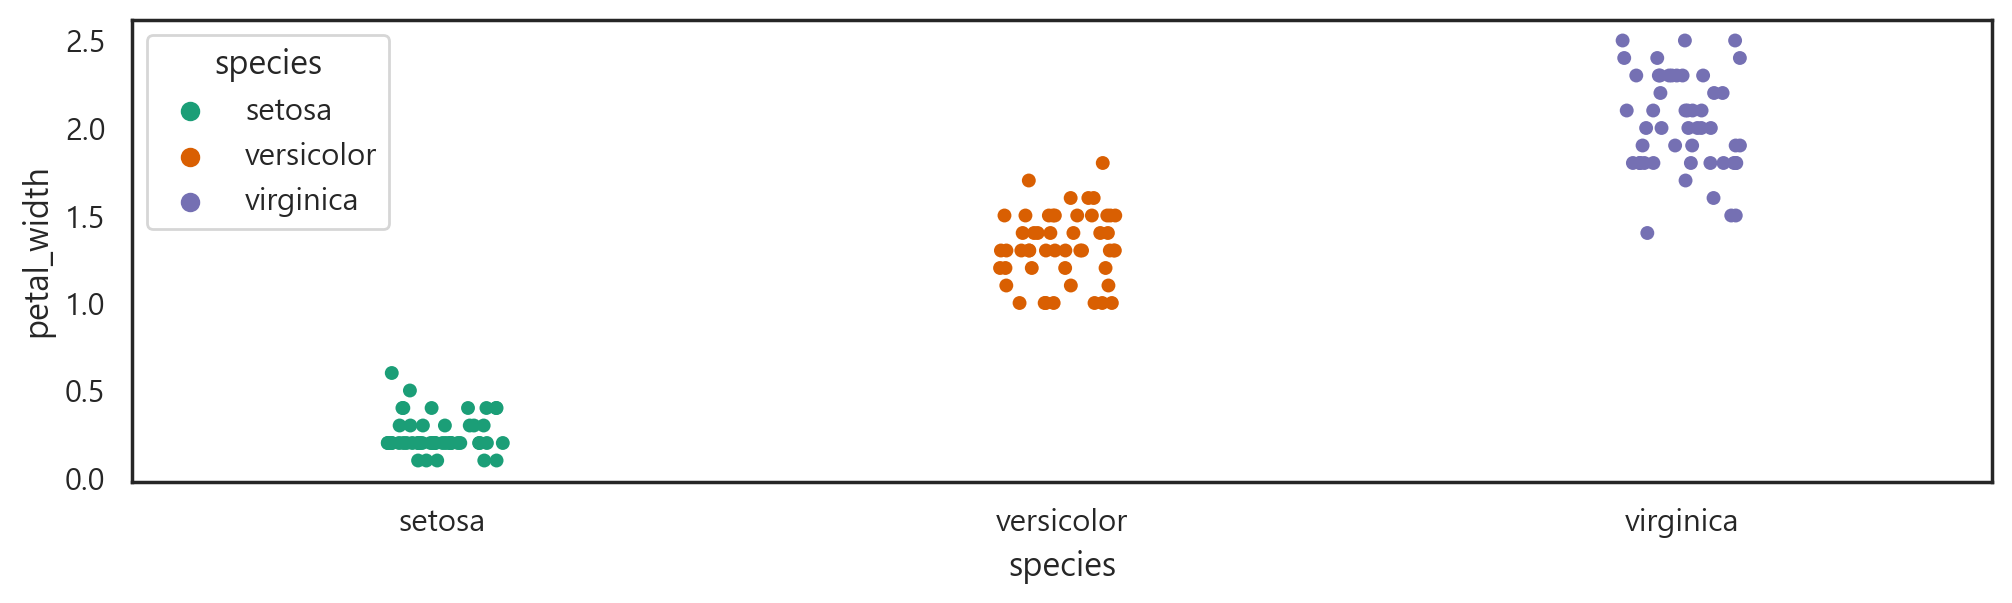

In [11]:
# x축이 범주형 데이터일때 산점도(중첩된점):랜덤으로 좌우로 흩뿌린다.)
sns.stripplot(data=iris, x='species',y='petal_width',
               hue='species',palette='Dark2')
plt.show()

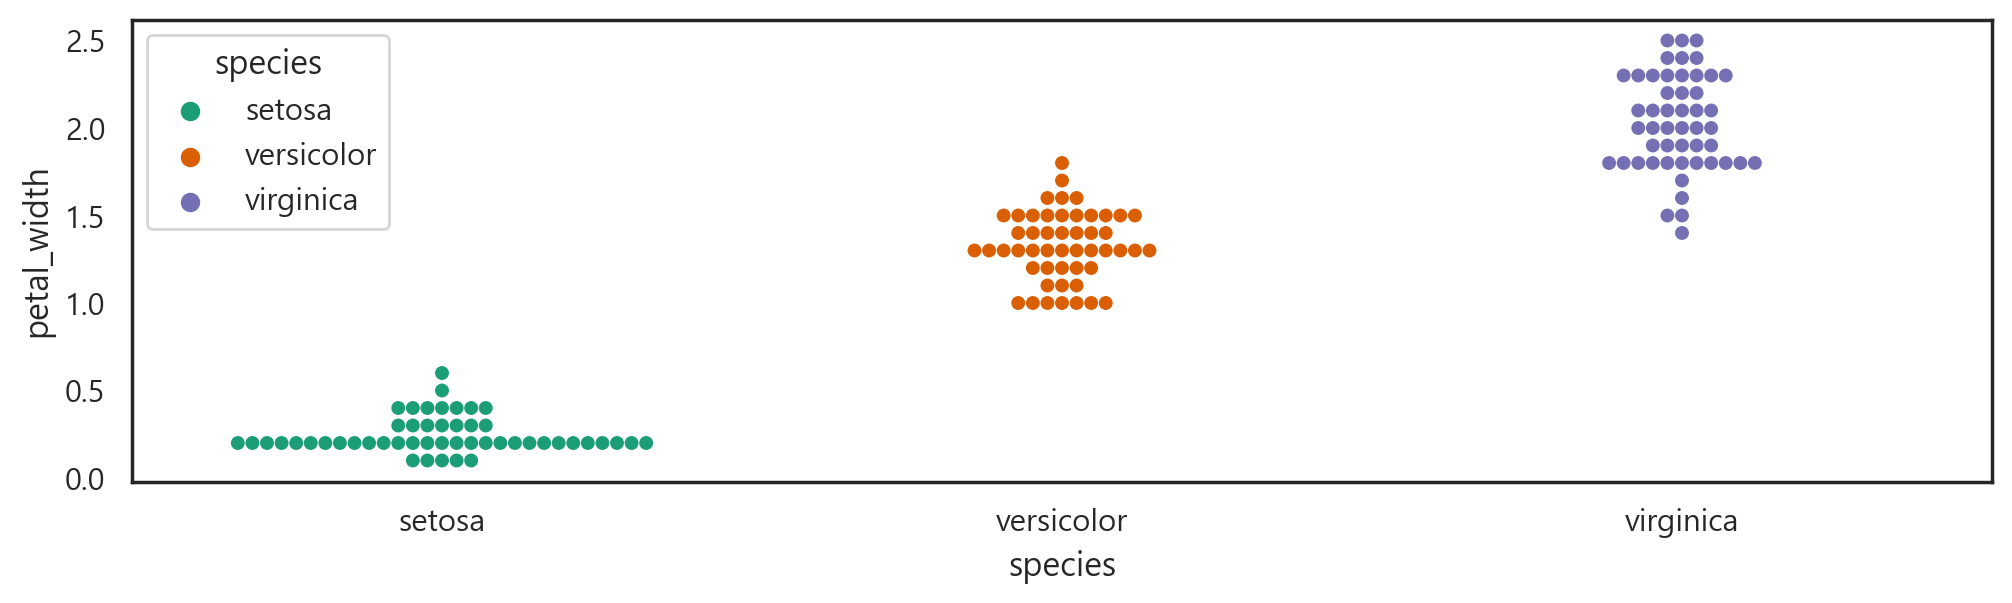

In [12]:
#x축이 범주형 데이터일때 산점도(중첩되지 않게)
sns.swarmplot(data=iris, x='species',y='petal_width',
               hue='species',palette='Dark2',#size=3
             )
plt.show()

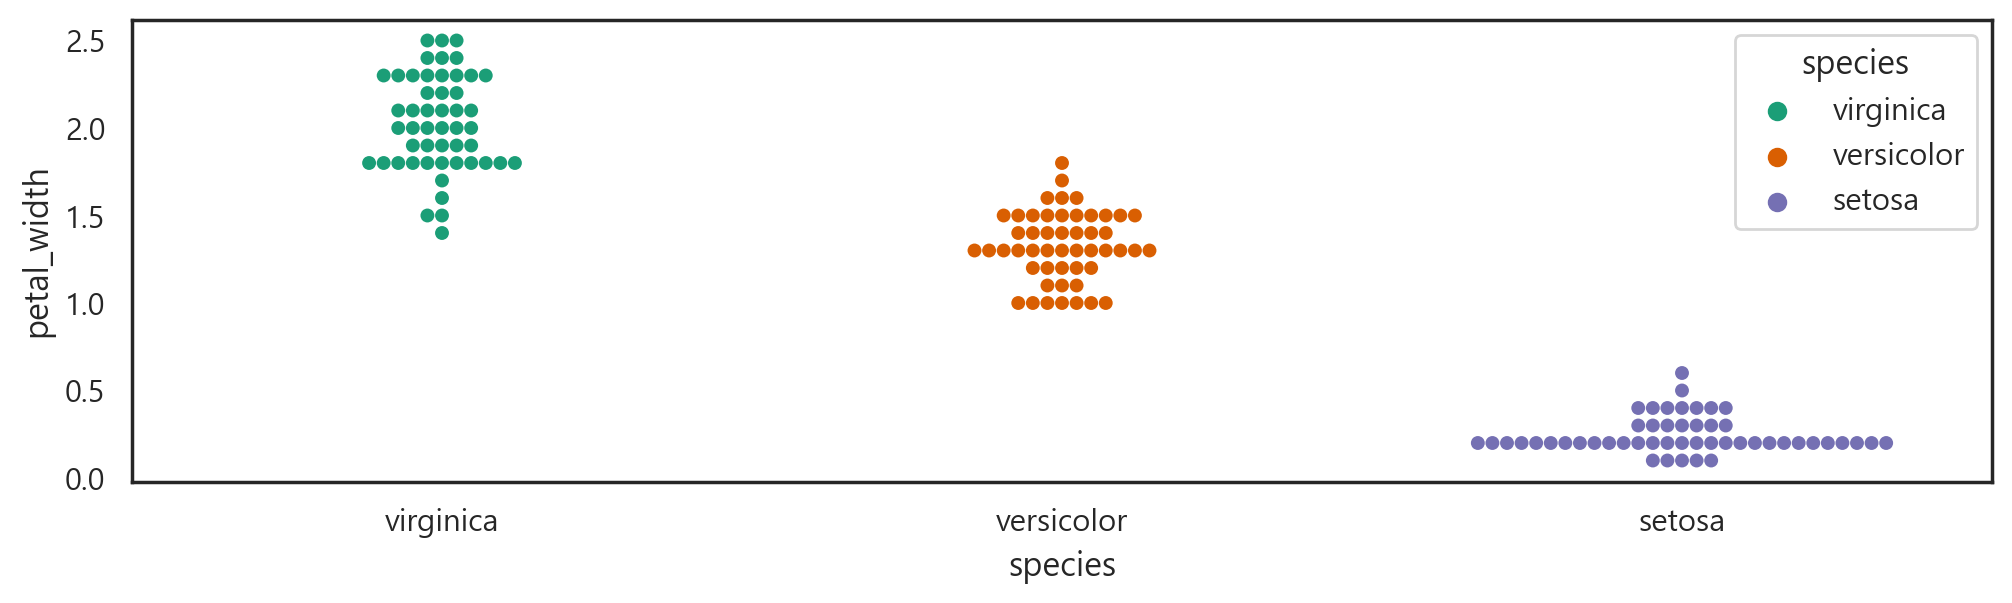

In [14]:
# petal_width 내림차순 정렬된 iris로 종별 산점도
sns.swarmplot(data=iris.sort_values('petal_width',ascending=False),
             x='species',
             y='petal_width',
             hue='species',
             palette='Dark2')
plt.show()

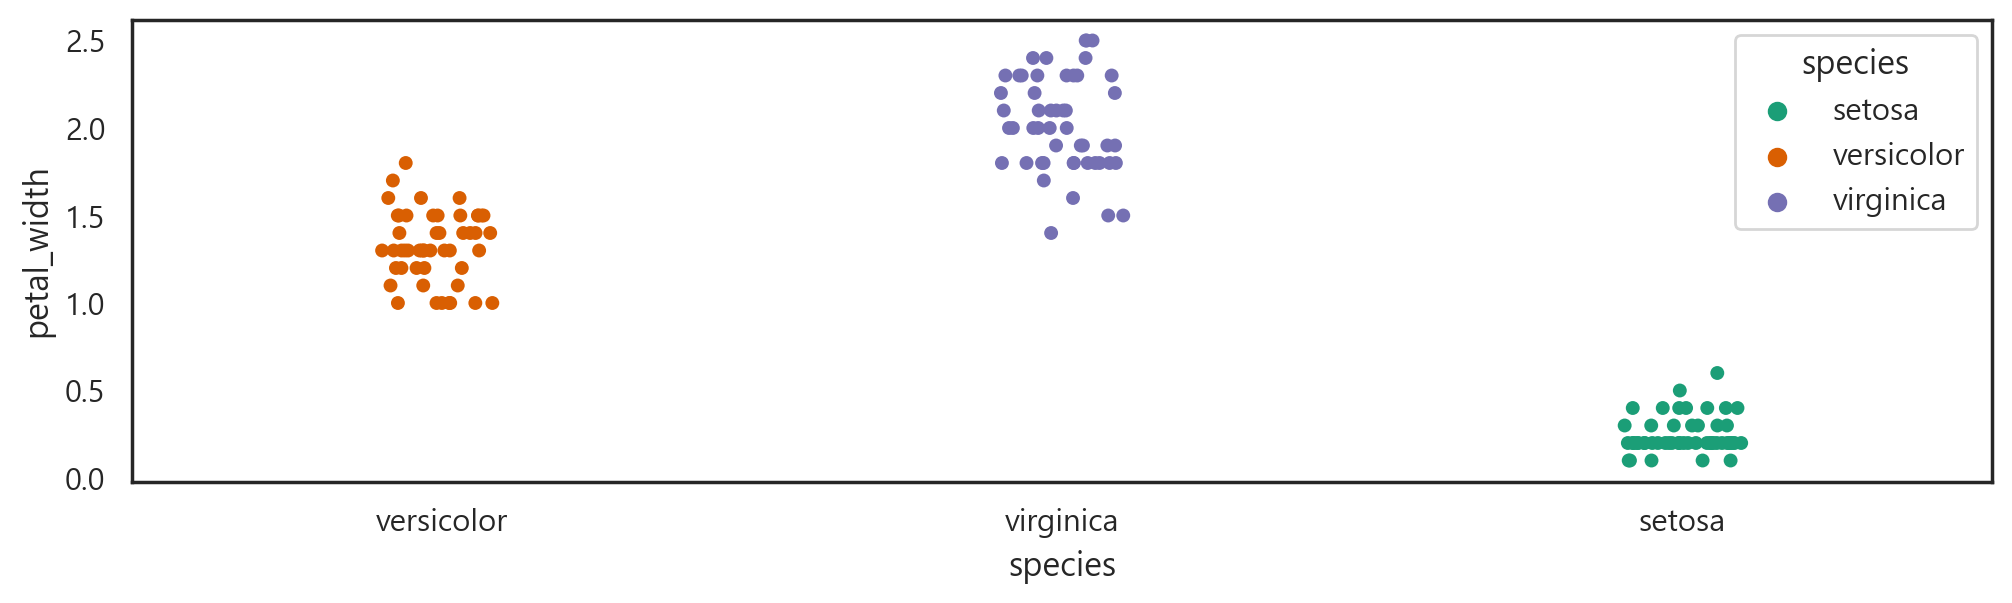

In [16]:
# x축 순서를 임의로 정할수있음
sns.stripplot(data=iris,
             x='species',
             y='petal_width',
             order=['versicolor','virginica','setosa'],#x측순서
             hue='species') 
plt.show()

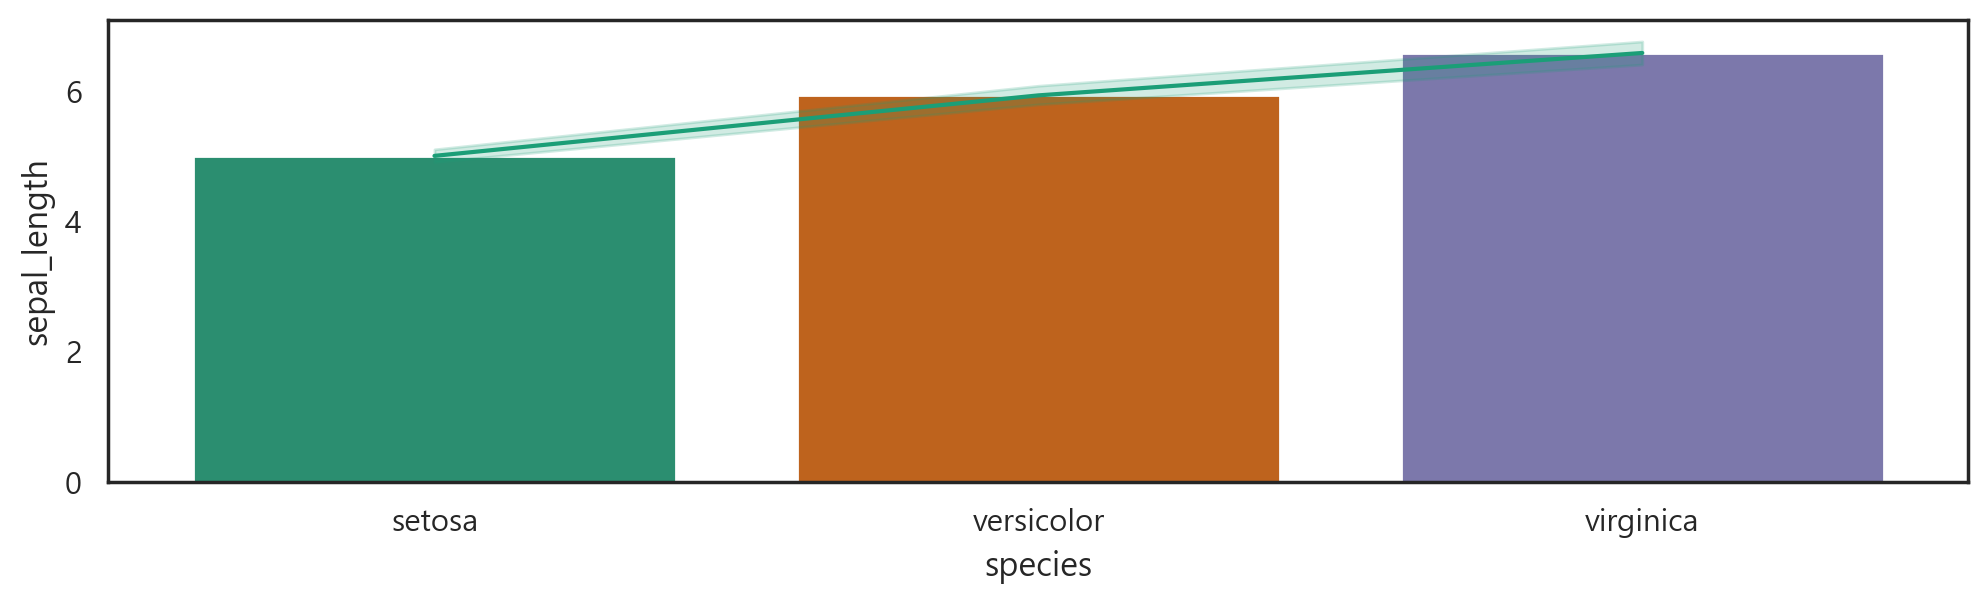

In [20]:
# barplot  : 각 변주별 평균값과 그에 대한 신뢰구간(ci:Confidence Interval)을 막대 그래프
sns.barplot(data=iris,
           x='species',
           y='sepal_length',
           errorbar=None,# ci 구간을 안그리고 막대만
           #estimator='sum'
           )
sns.lineplot(data=iris,
            x='species',
            y='sepal_length')
plt.show()

<Axes: xlabel='species', ylabel='sepal_length'>

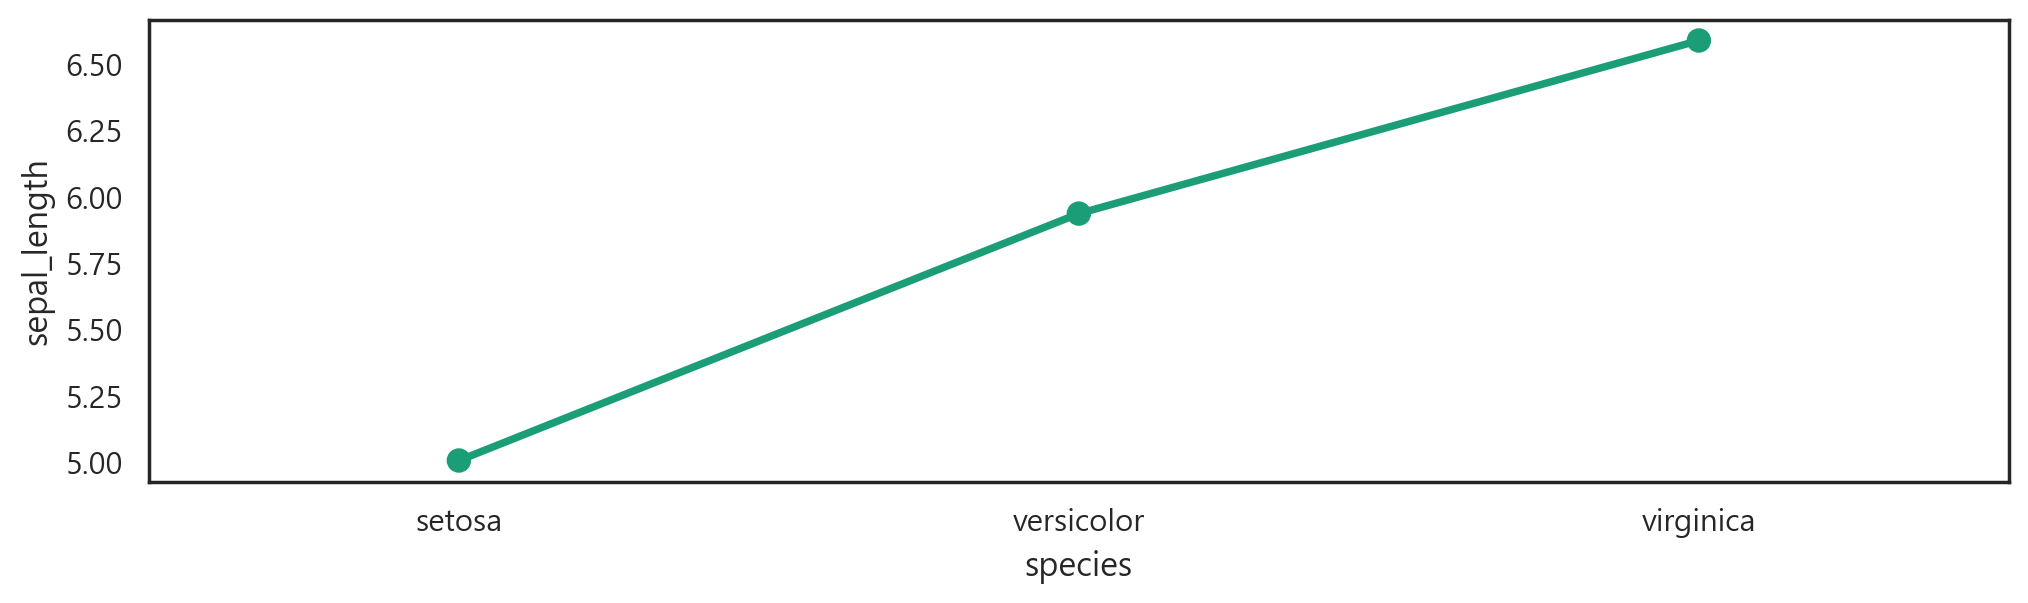

In [24]:
sns.pointplot(data=iris,
           x='species',
           y='sepal_length',
           errorbar=None
             )

In [25]:
# Survived : 생존 여부 (0 = 사망, 1 = 생존)
# Pclass : 티켓 클래스 (1 = 1등석, 2 = 2등석, 3 = 3등석)
# Sex : 성별
# Age : 나이
# SibSp : 함께 탑승한 자녀 / 배우자 의 수
# Parch : 함께 탑승한 부모님 / 아이들 의 수
# Ticket : 티켓 번호
# Fare : 탑승 요금
# Cabin : 수하물 번호
# Boat : 탈출한 보트가 있다면 boat 번호
# Embarked : 선착장 (C = Cherbourg, Q = Queenstown, S = Southampton)
# Pclass : 승객 클래스(1 = 1등석; 2 = 2등석; 3 = 3등석)

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


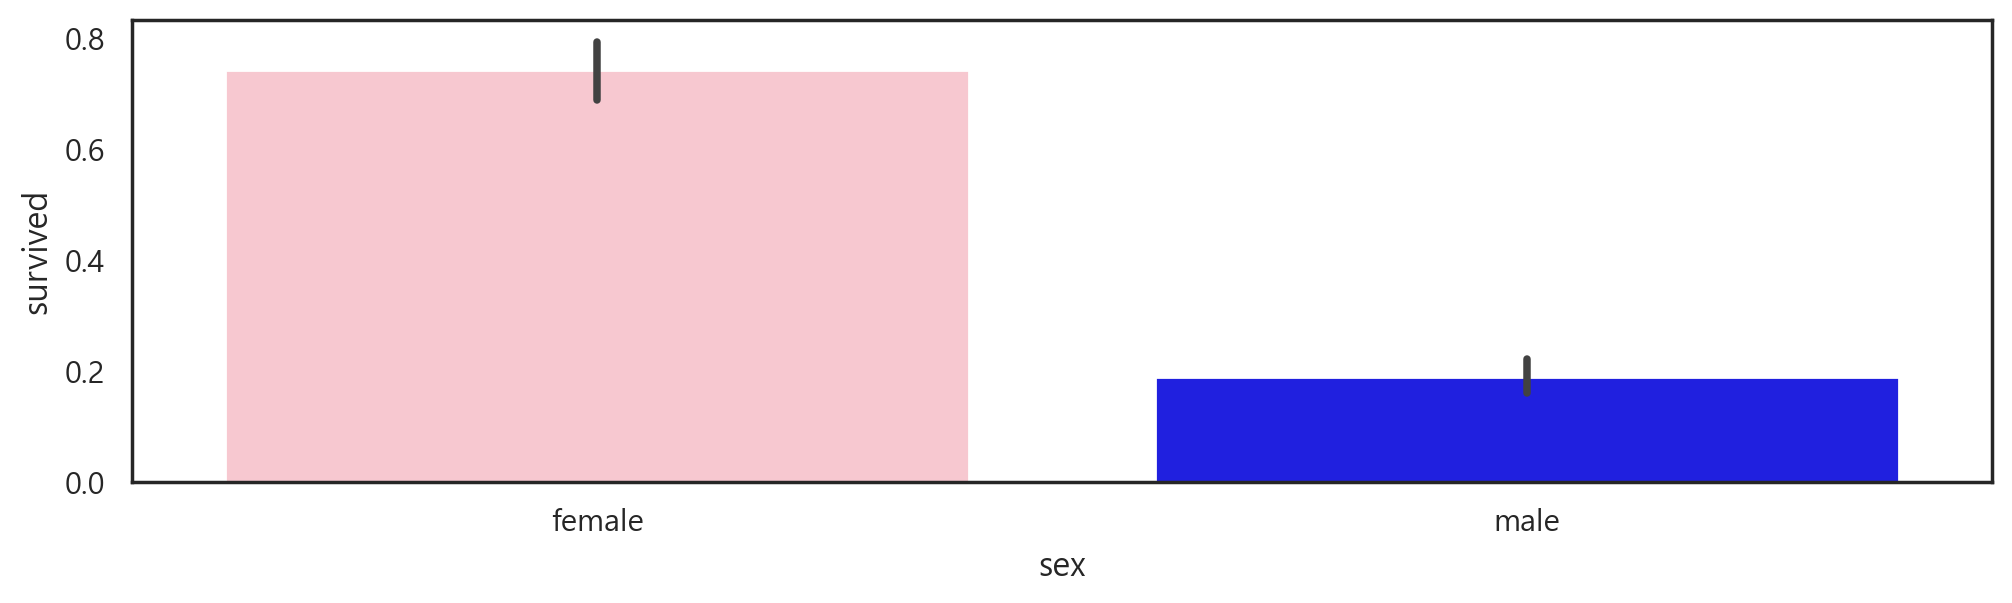

In [29]:
#titanic의 성별 평균 생존률
# titanic.groupby('sex')['survived'].mean()
sns.barplot(data=titanic, x='sex',y='survived',
            order=['female','male'],
            palette=['pink','blue'])
plt.show()

In [30]:
titanic['sex'].unique()

array(['male', 'female'], dtype=object)

In [33]:
# 성별 데이터
# titanic.groupby('sex')['survived'].count().sort_values(ascending=False)
titanic['sex'].value_counts() # 내림차순 정렬

male      577
female    314
Name: sex, dtype: int64

In [43]:
# 남자 중 생존자와 비생존자
print('남자 생존자수:',titanic[(titanic['sex']=='male') & (titanic['survived']==1)].shape[0])
print('남자 생존자수:',len(titanic[(titanic['sex']=='male') & (titanic['survived']==1)]))    
print('남자 비생존자수:', titanic[(titanic['sex']=='male') & (titanic['survived']==0)].shape[0])
print('남자 생존자수:',len(titanic[(titanic['sex']=='male') & (titanic['survived']==0)]))

남자 생존자수: 109
남자 생존자수: 109
남자 비생존자수: 468
남자 생존자수: 468


In [44]:
print('여자 생존자수:',titanic[(titanic['sex']=='female') & (titanic['survived']==1)].shape[0])
print('여자 생존자수:',len(titanic[(titanic['sex']=='female') & (titanic['survived']==1)]))    
print('여자 비생존자수:', titanic[(titanic['sex']=='female') & (titanic['survived']==0)].shape[0])
print('여자 생존자수:',len(titanic[(titanic['sex']=='female') & (titanic['survived']==0)]))

여자 생존자수: 233
여자 생존자수: 233
여자 비생존자수: 81
여자 생존자수: 81


<Axes: xlabel='class', ylabel='survived'>

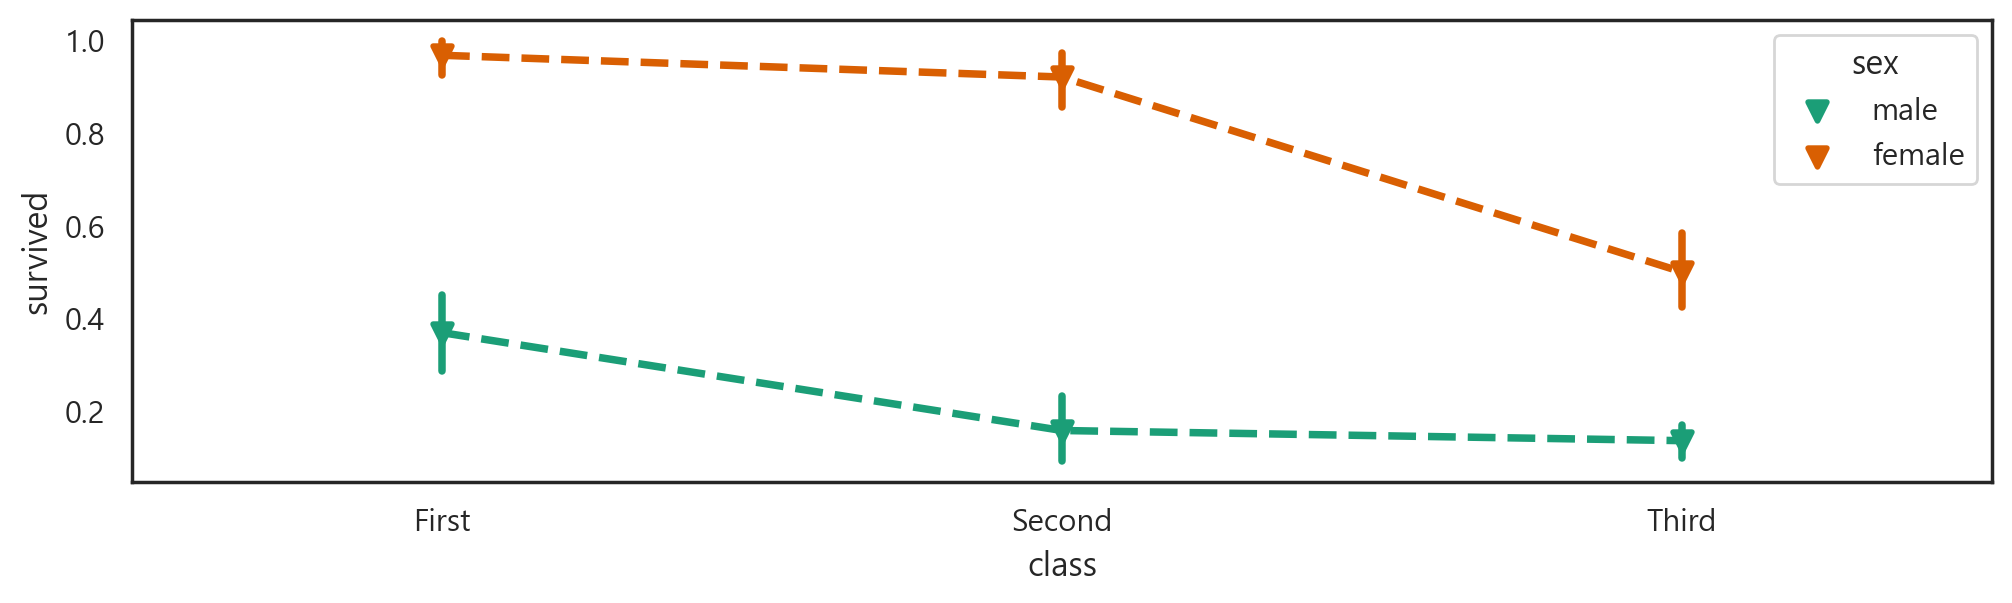

In [68]:
# class별 성별 생존율
sns.pointplot(data=titanic,x='class',y='survived',
             hue='sex',
             markers='v',linestyles='--')
# plt.show()
# sns.pointplot(
#     data=titanic, 
#     x='class', 
#     y='survived',
#     hue='sex',
#     markers='v',      # 둘 다 'v' 마커 사용
#     linestyles='--'   # 둘 다 점선('--') 사용


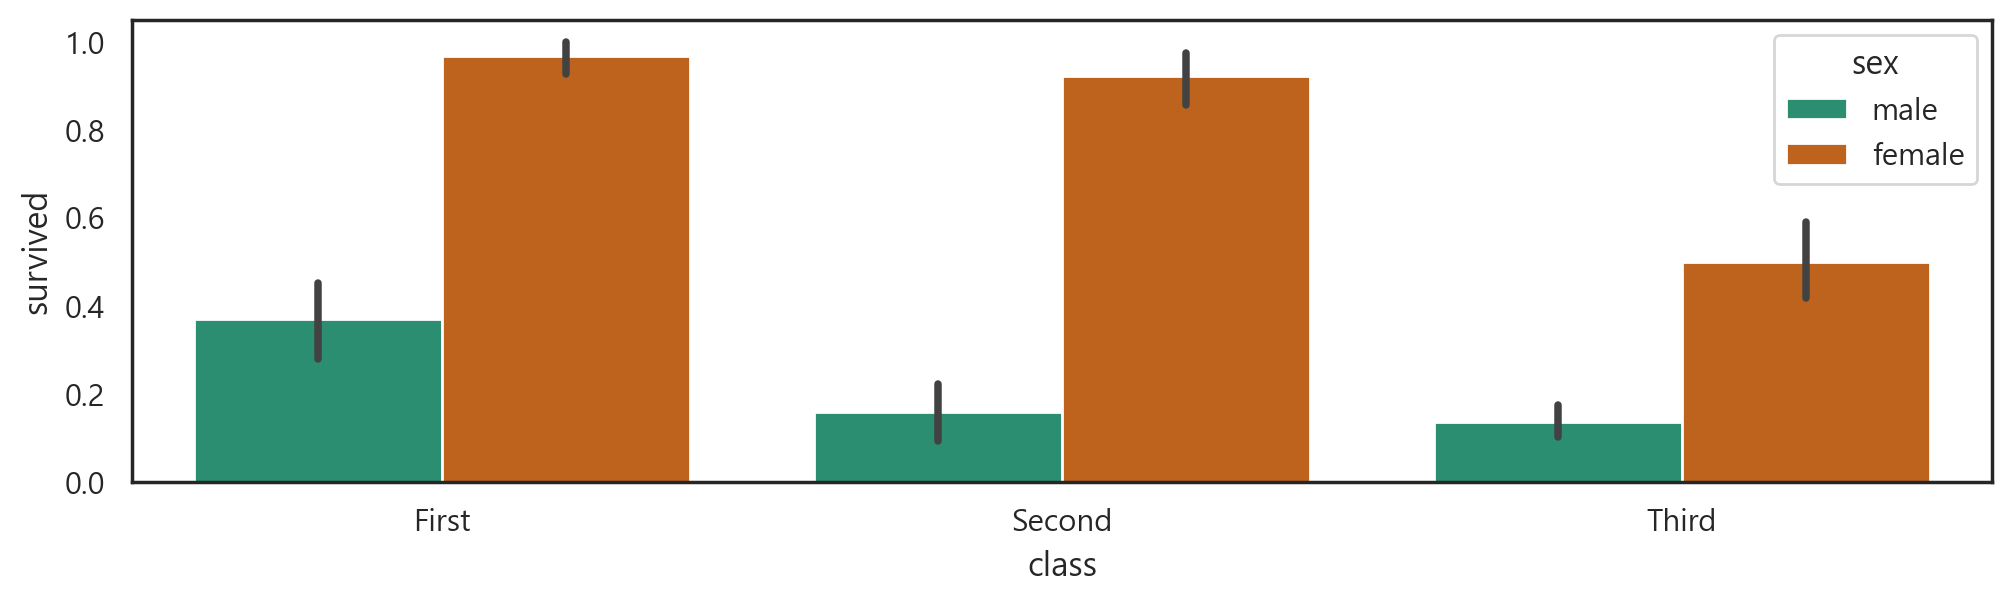

In [42]:
# class별 성별 생존율
sns.barplot(data=titanic,x='class',y='survived',hue='sex')
plt.show()

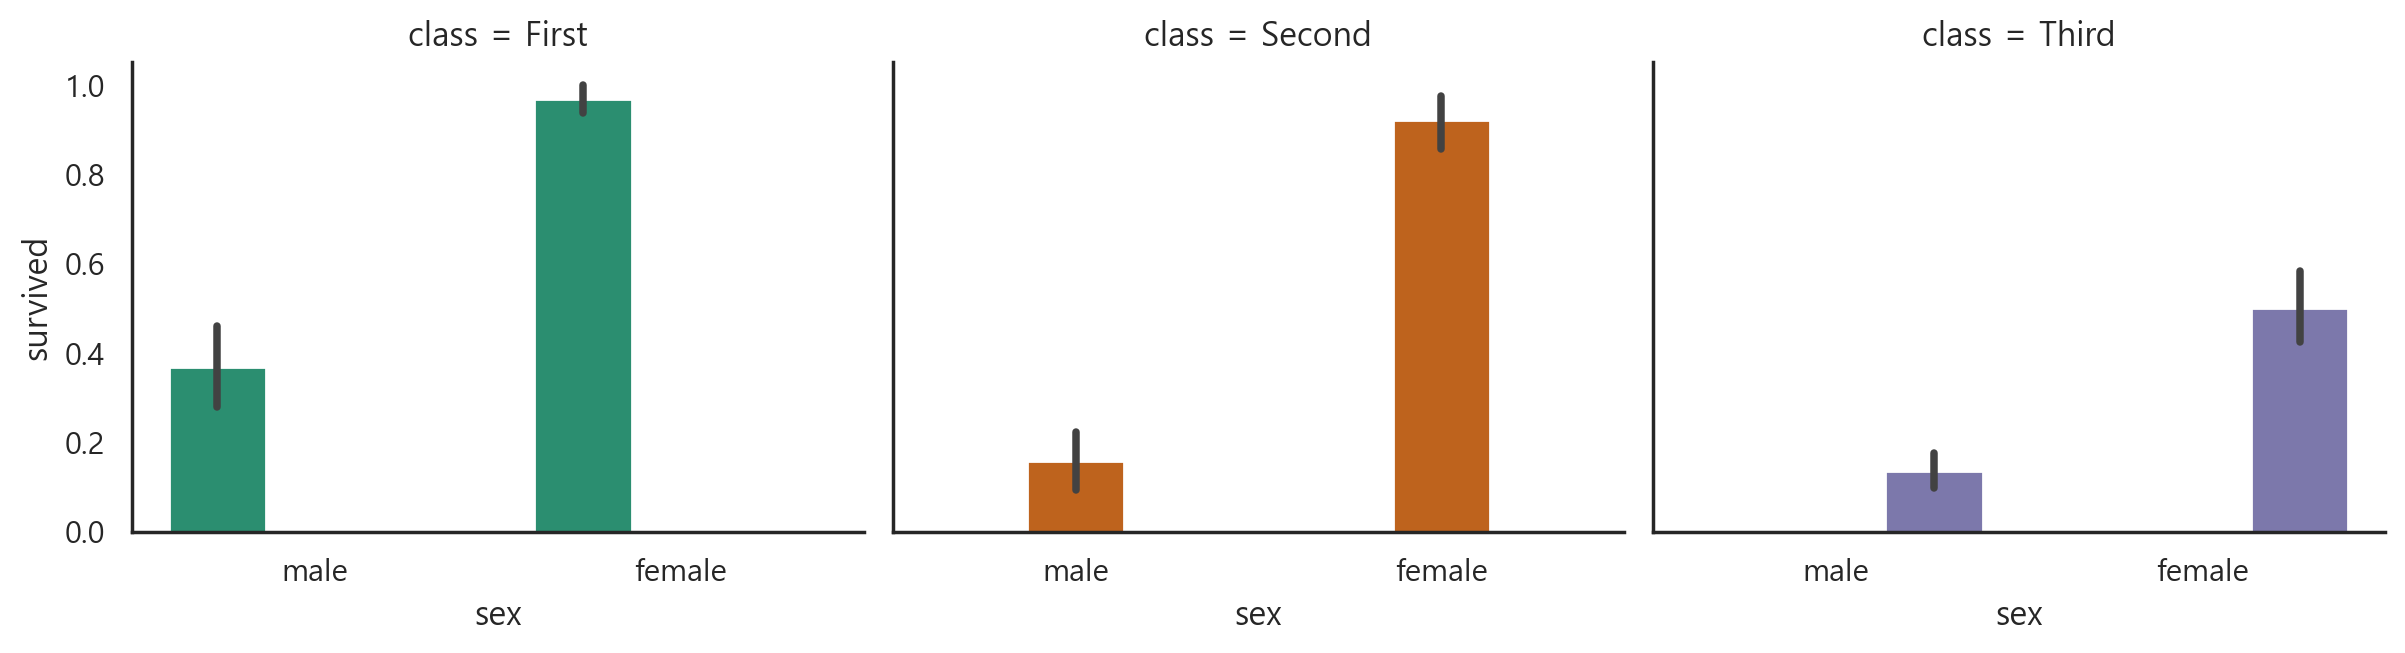

In [50]:
# class별로 성별 생존률 서브 플롯으로 
g=sns.catplot(data=titanic,
             x='sex',
             y='survived',
             kind='bar', # 기본값은 stripplot
             col='class',
             hue='class',
             #col=wrap=2 #한방에 그려질 서브플롯 수 
             )
g.fig.set_size_inches(12,3)

In [58]:
order =titanic.groupby('deck')['survived'].mean().sort_values(ascending=False).index

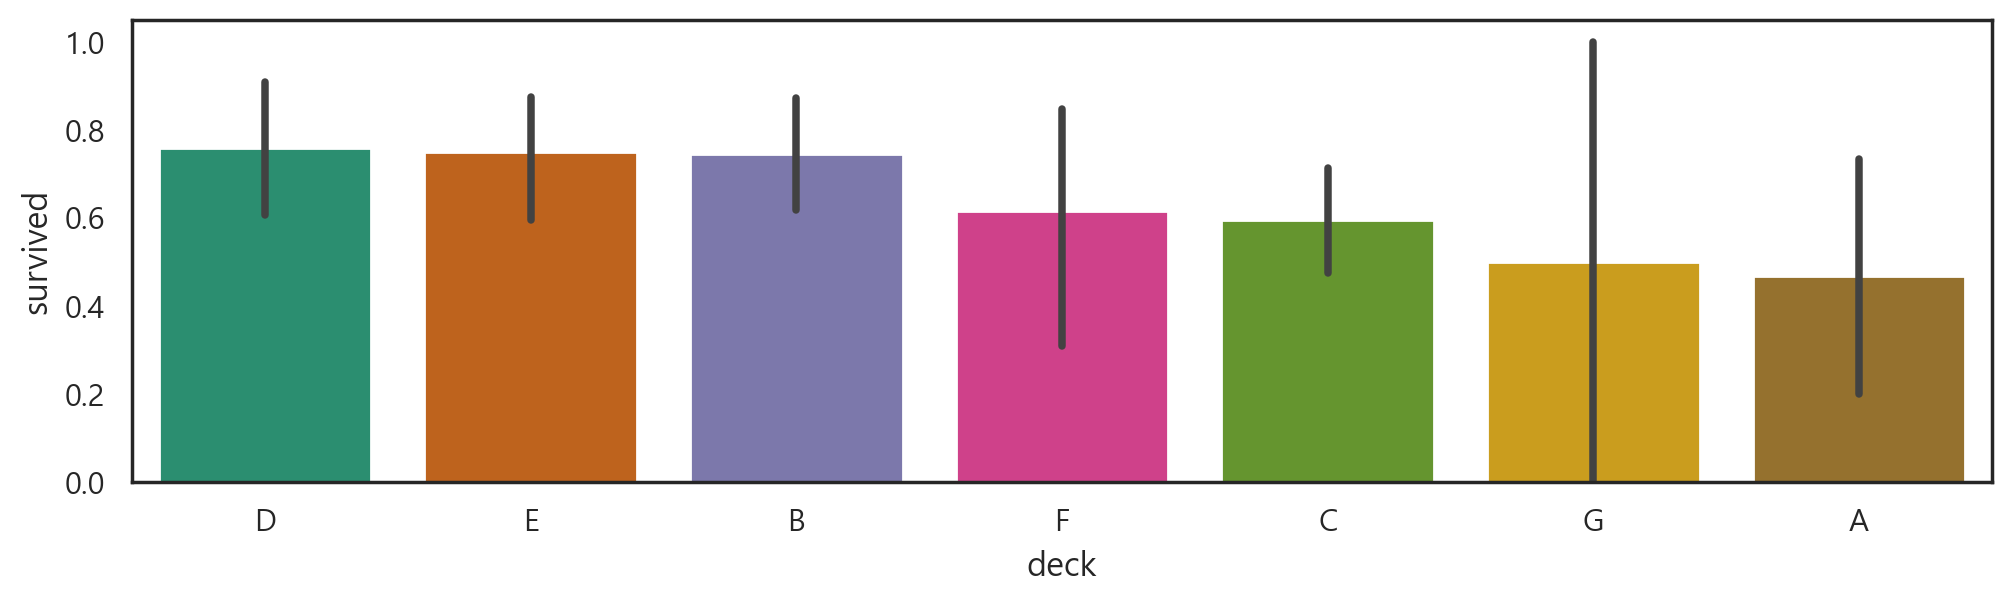

In [59]:
# deck별 생존률(결측치가 많아 신뢰도 낮음)
sns.barplot(data=titanic,
            x='deck',y='survived',
            order=order)
plt.show()

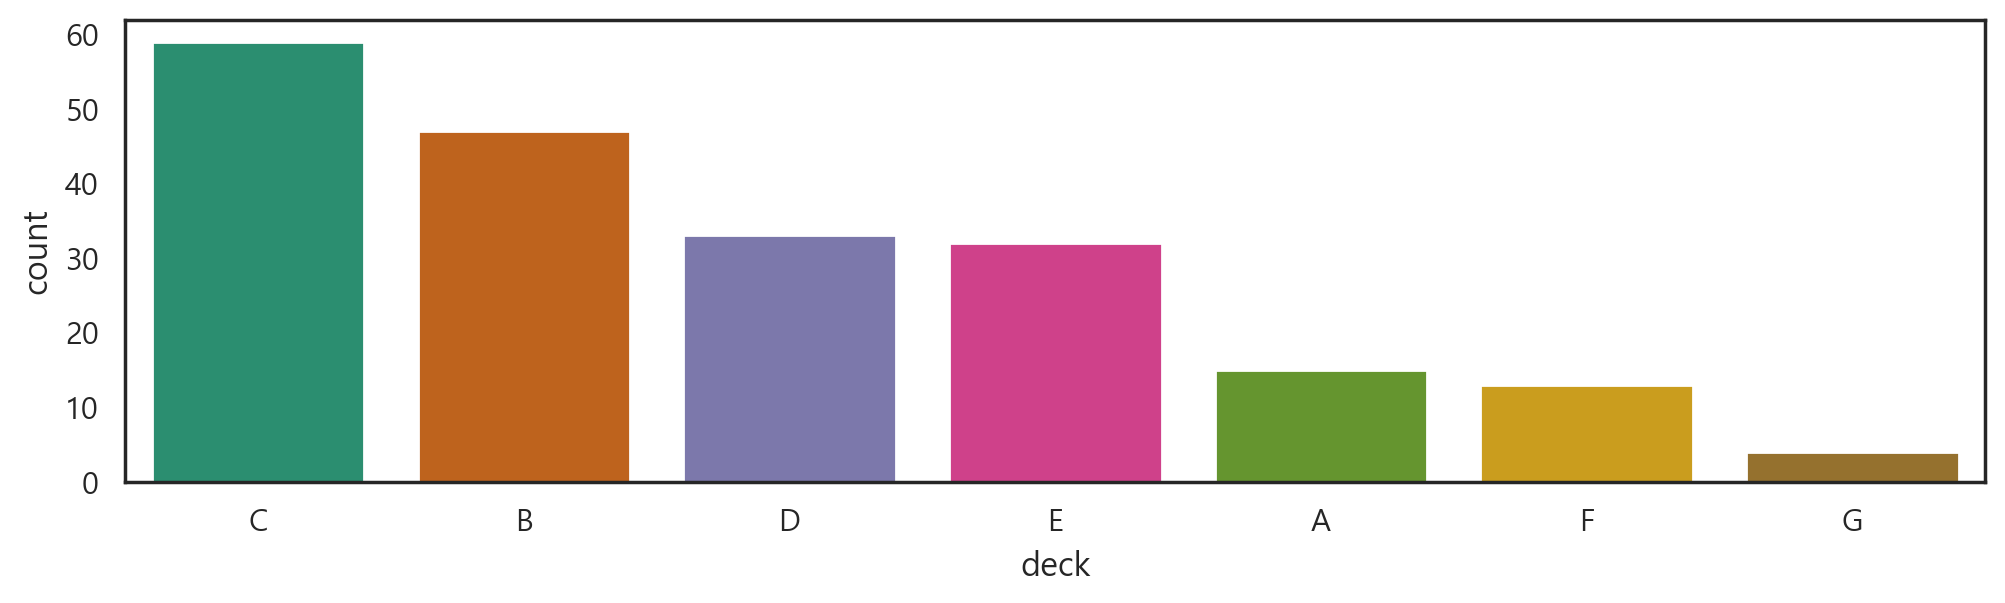

In [62]:
# deck별 데이터 수를 막대그래프
order=titanic.deck.value_counts().index
sns.countplot(data=titanic, x='deck',order=order)
plt.show()

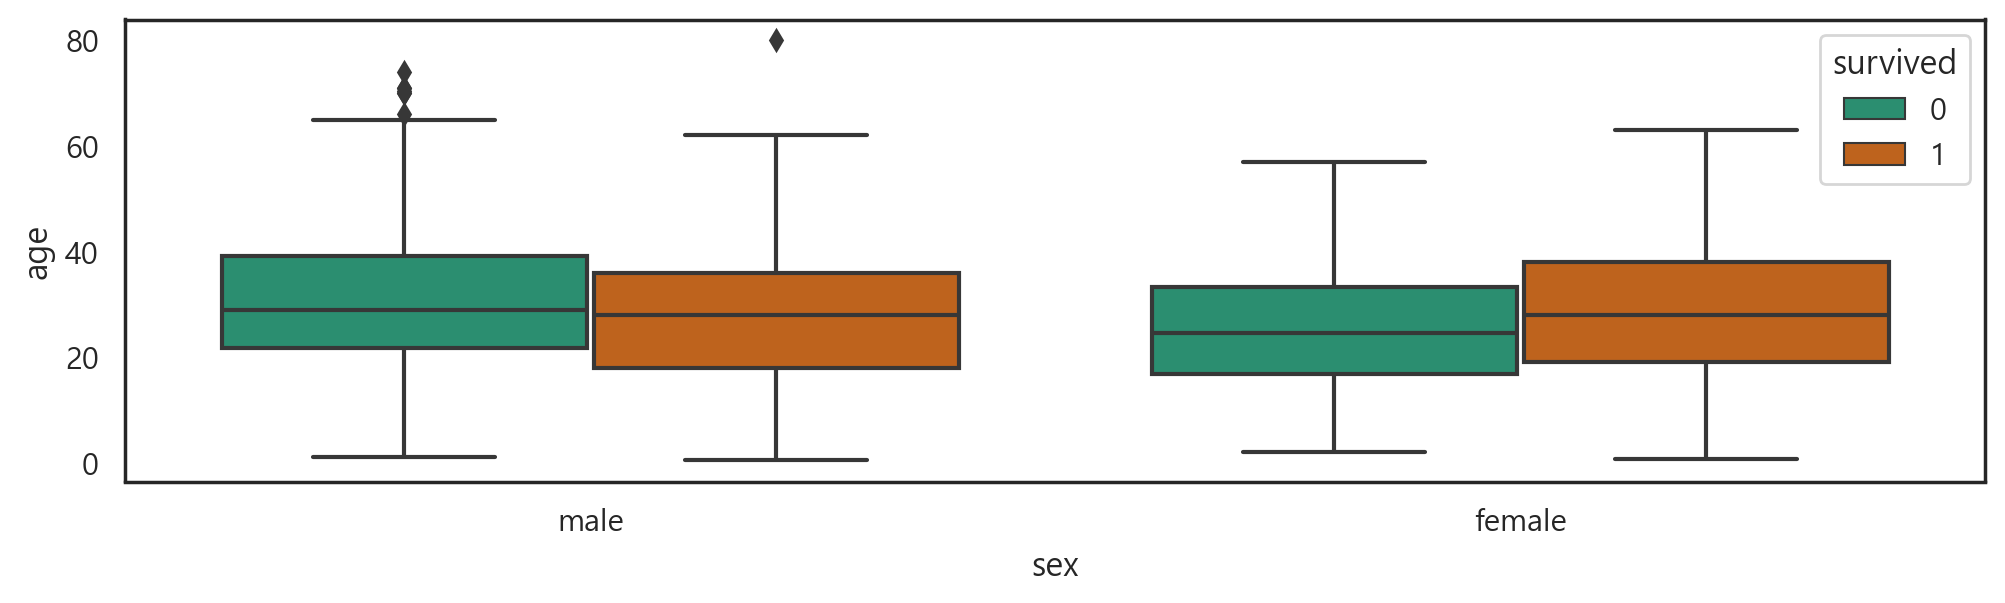

In [73]:
# boxplot (4사분위수와 이상치 판별. 분포는 모름)=>boxenplot,violinplot
sns.boxplot(data=titanic, x='sex',y='age',hue='survived')
plt.show()

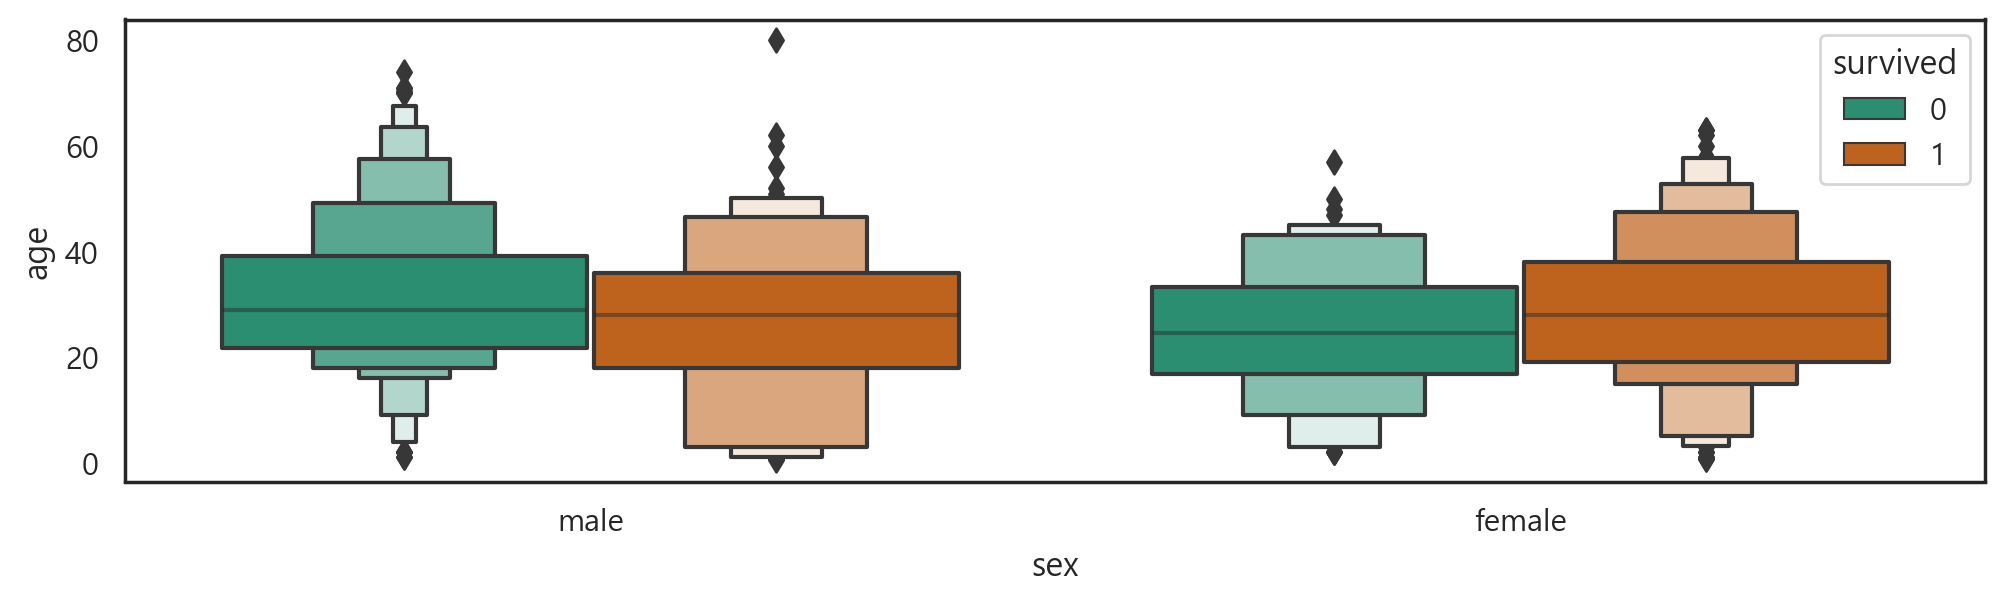

In [74]:
sns.boxenplot(data=titanic, x='sex',y='age',hue='survived')
plt.show()

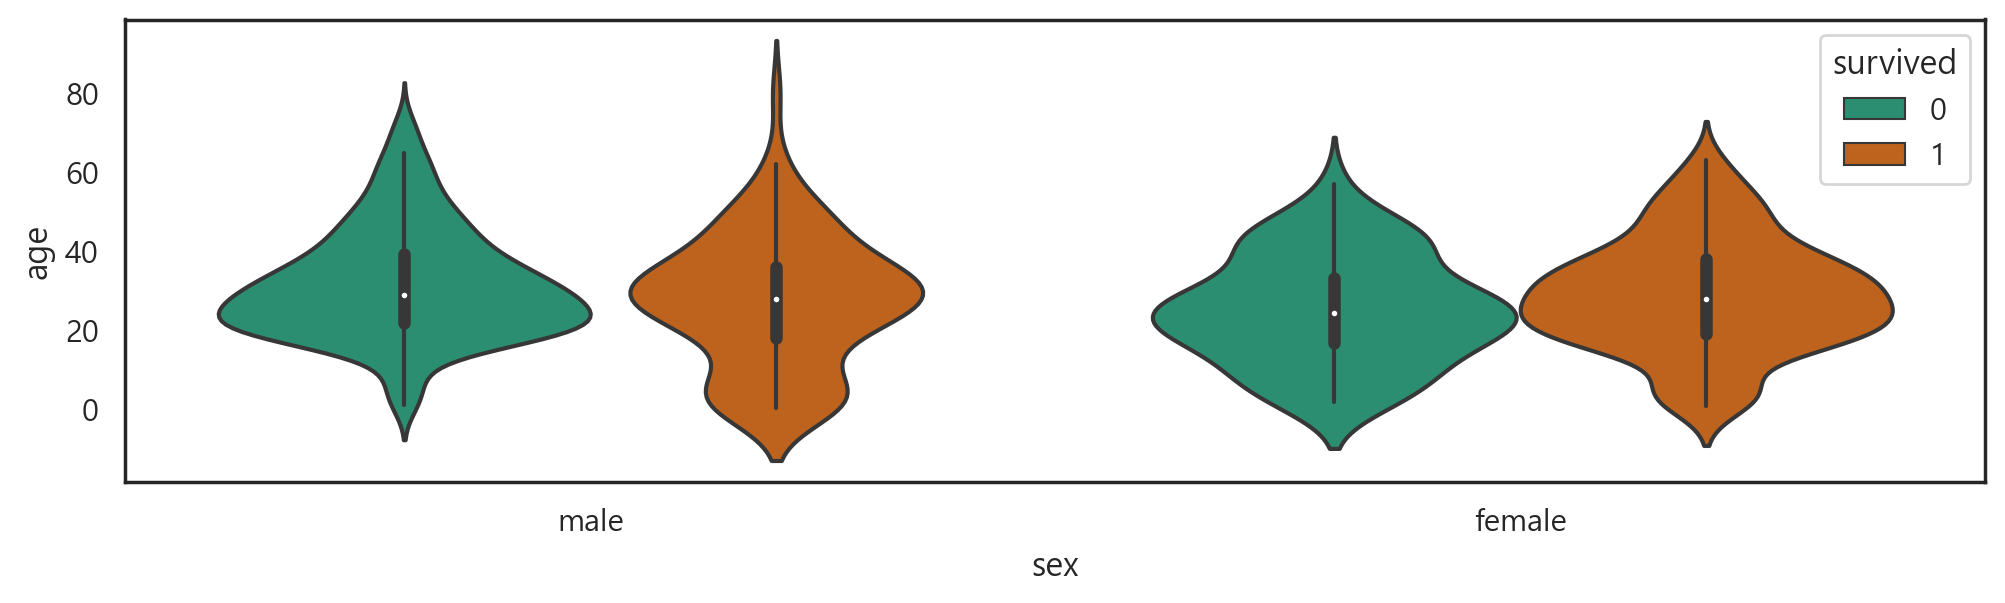

In [75]:
sns.violinplot(data=titanic, x='sex',y='age',hue='survived')
plt.show()

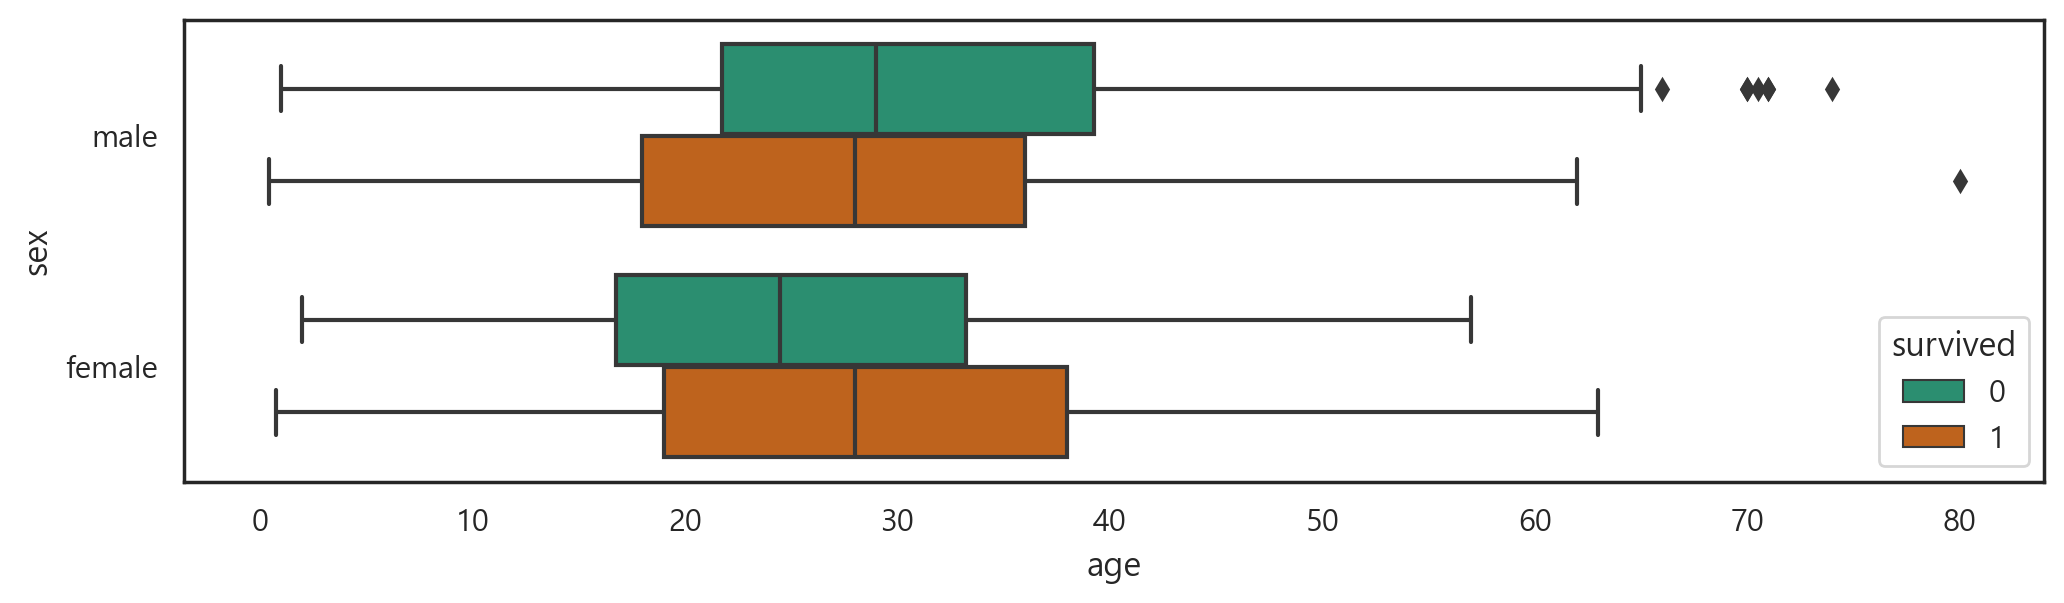

In [76]:
sns.boxplot(data=titanic, x='age',y='sex',hue='survived')
plt.show()

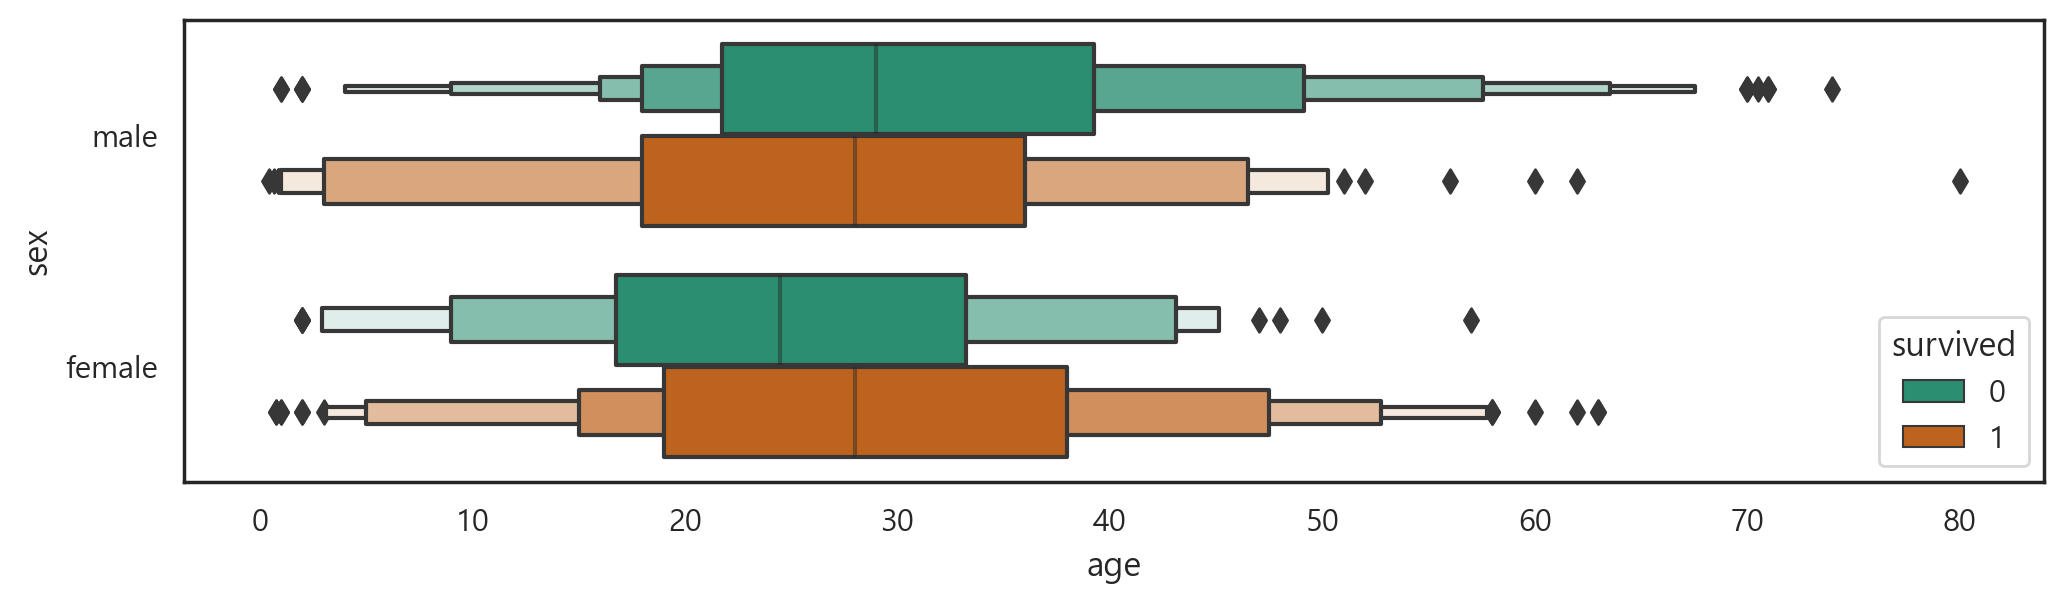

In [77]:
sns.boxenplot(data=titanic, x='age',y='sex',hue='survived')
plt.show()

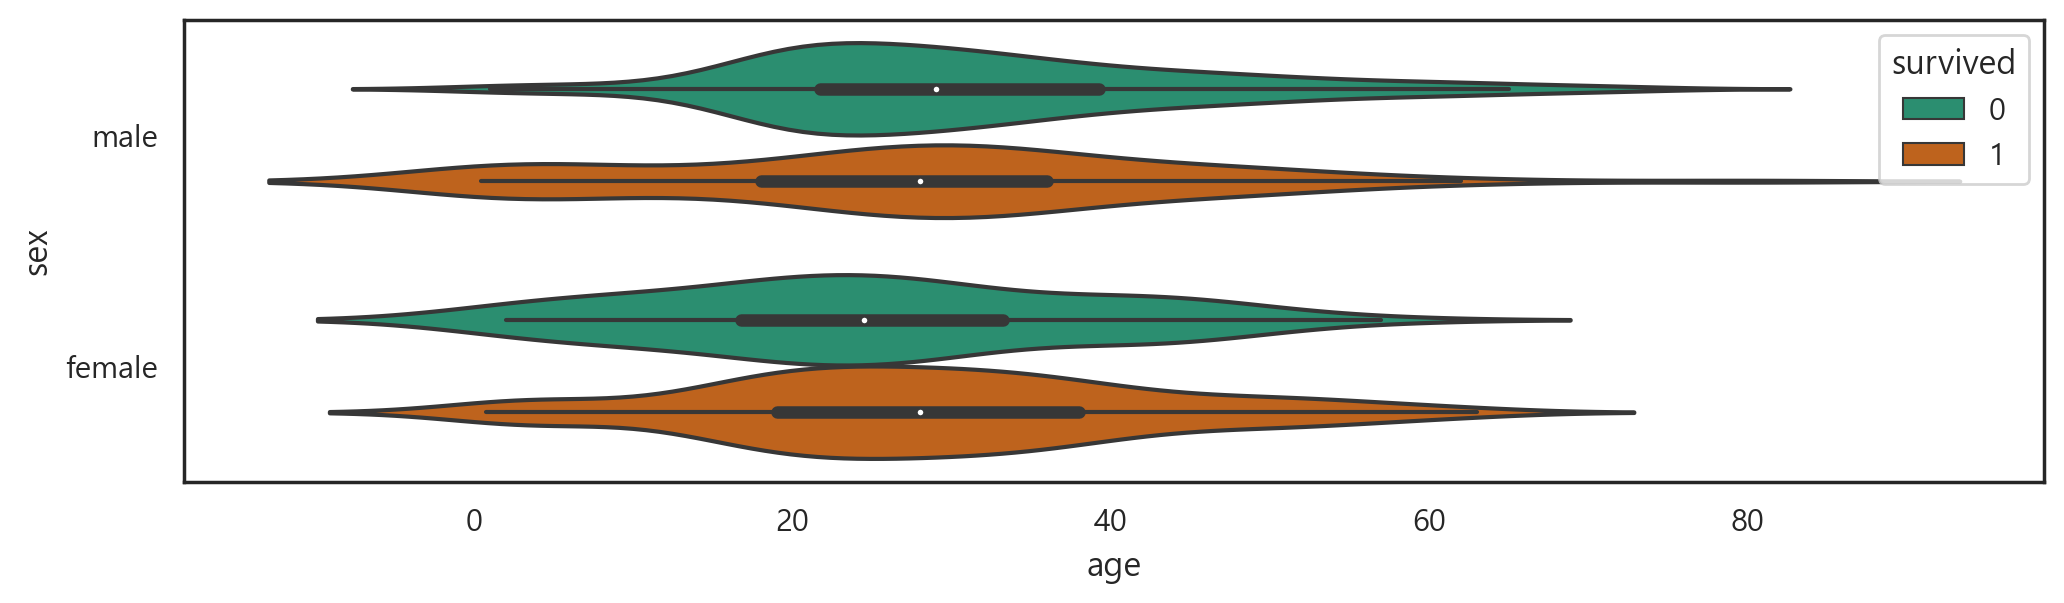

In [78]:
sns.violinplot(data=titanic, x='age',y='sex',hue='survived')
plt.show()

### 3)쌍관계그래프
- pairplot : 데이터 프래임에 포함된 모든 수치형 변수의 쌍에 대해 산점도(scatterplot)와 히스토그램(histogram)을 보여줌

In [87]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


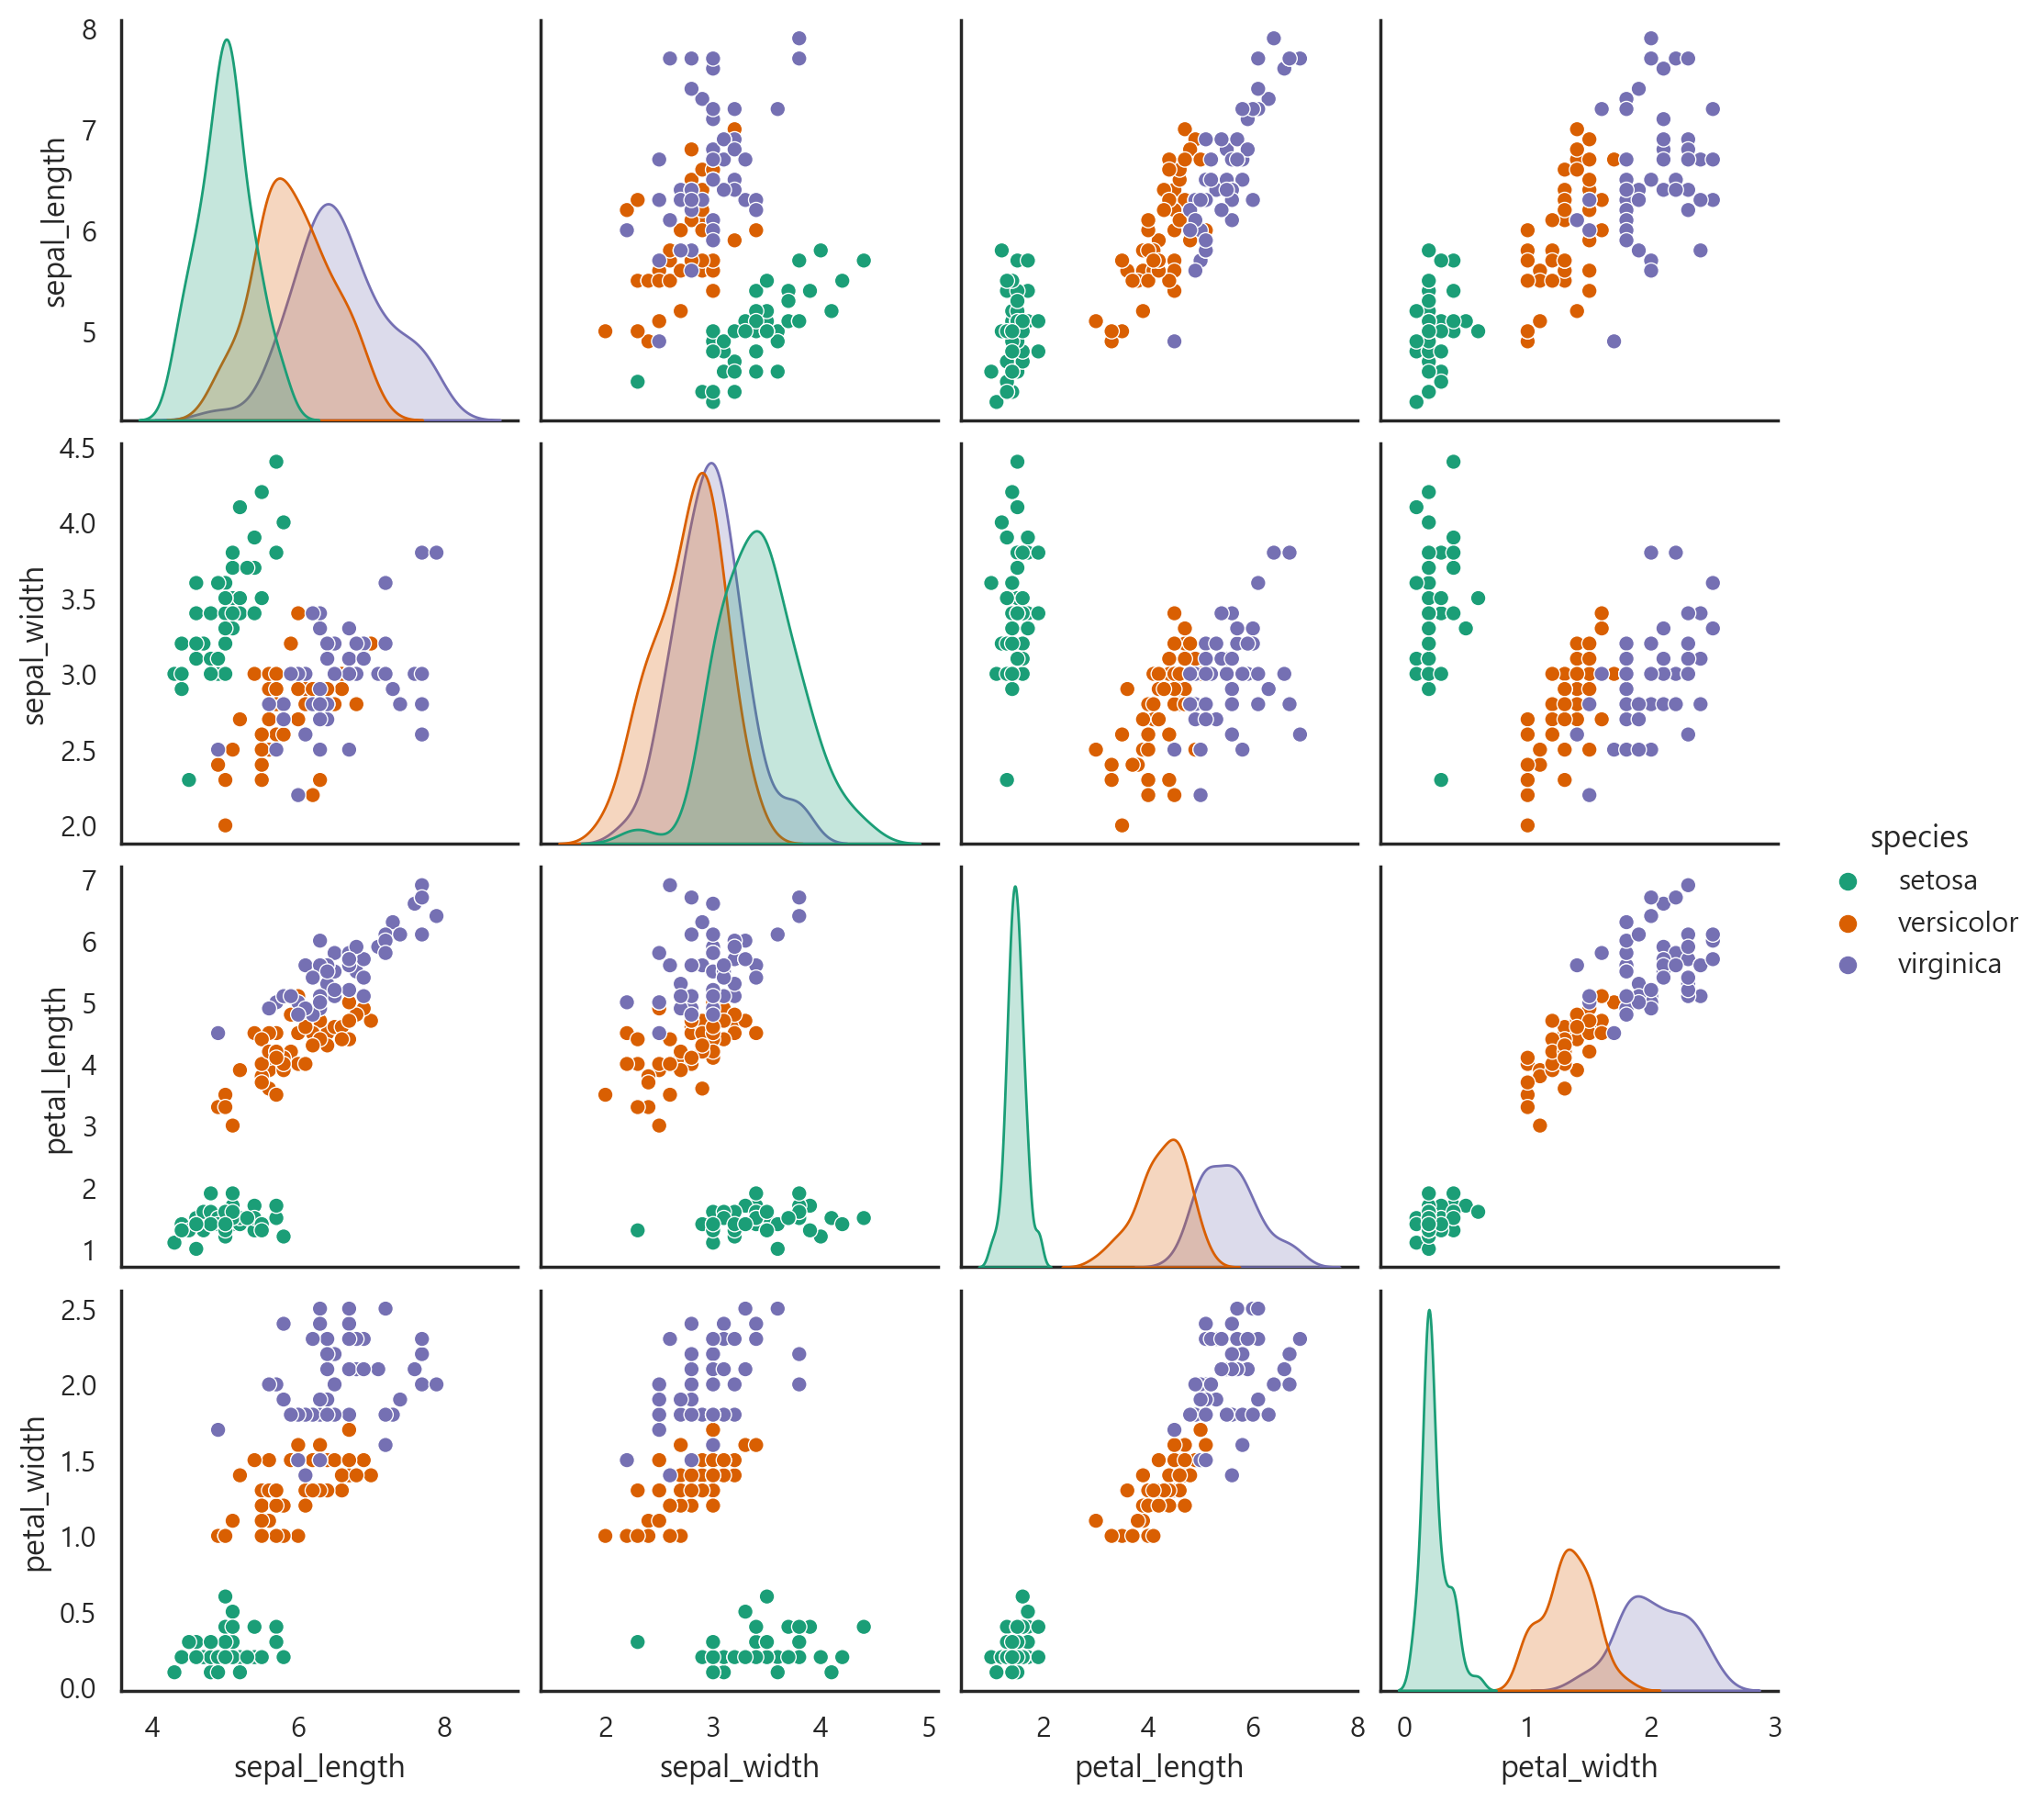

In [82]:
sns.pairplot(data=iris,hue='species')
plt.show()

### 4)밀도 그래프

In [90]:
import numpy as np
x = np.random.randn(10000) # 평균0, 표준편차 1인 정규분포로 10000개 데이터 배열
x.shape

(10000,)

<Axes: ylabel='Count'>

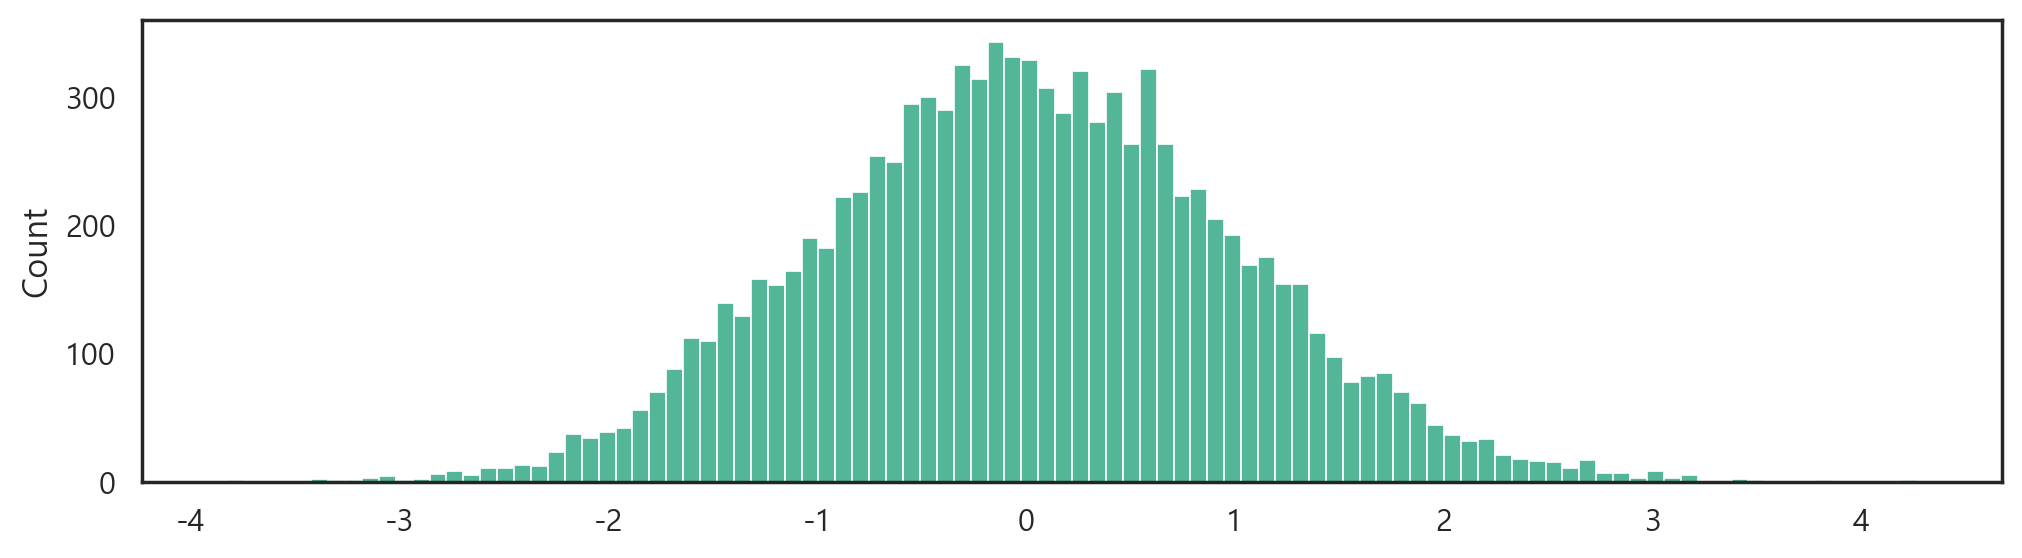

In [95]:
sns.histplot(x,bins=100)

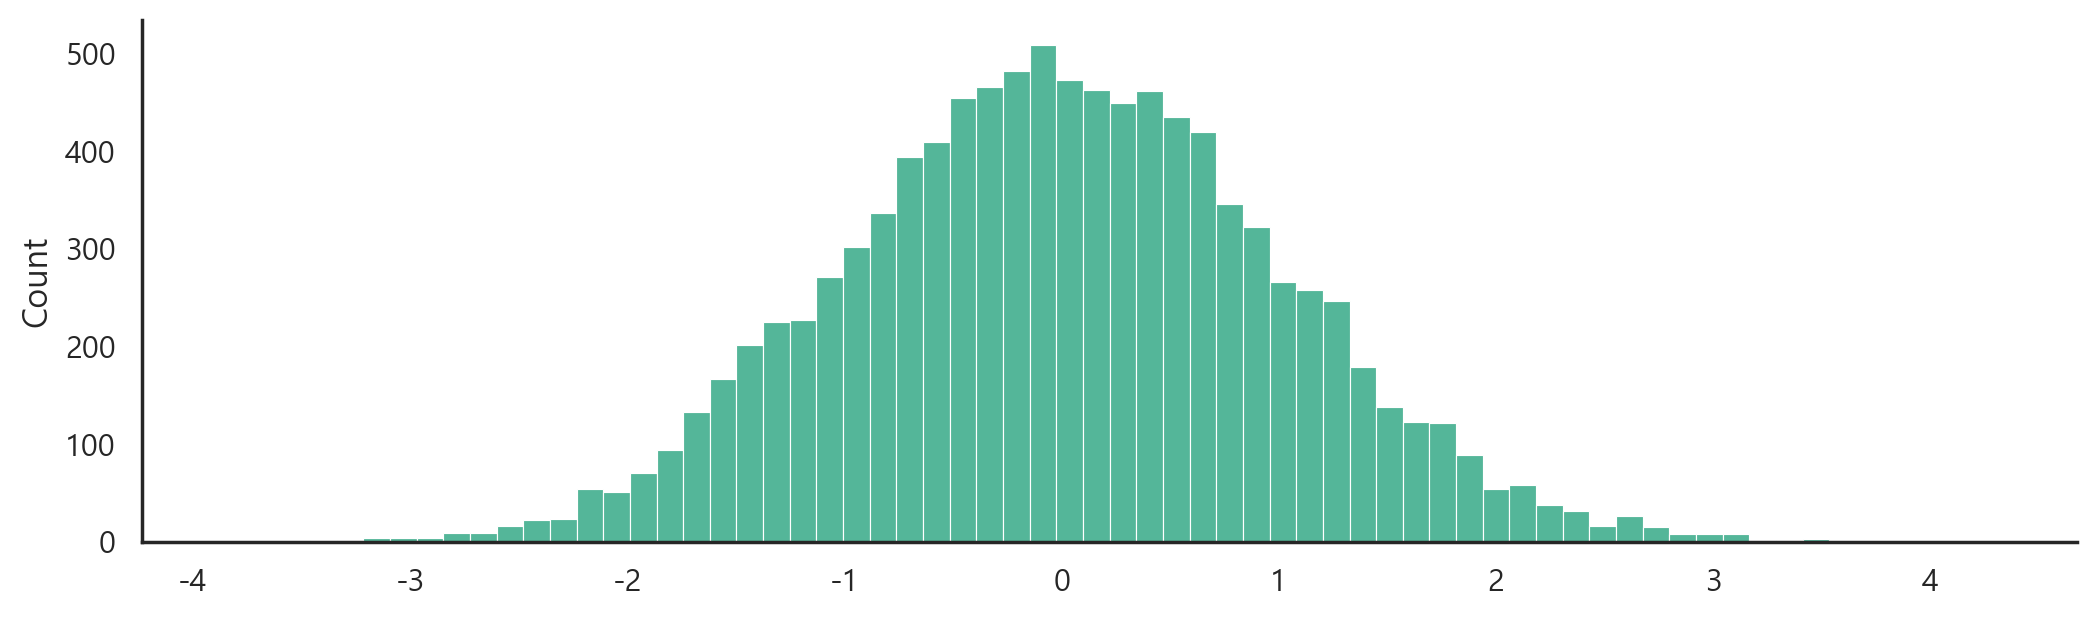

In [97]:
g=sns.displot(x)
g.fig.set_size_inches(12,3)

### 5)회귀 그래프
- regplot => lmplot(서브플롯)

In [101]:
corr=iris.corr(numeric_only=True)
corr=iris.iloc[:, :-1].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


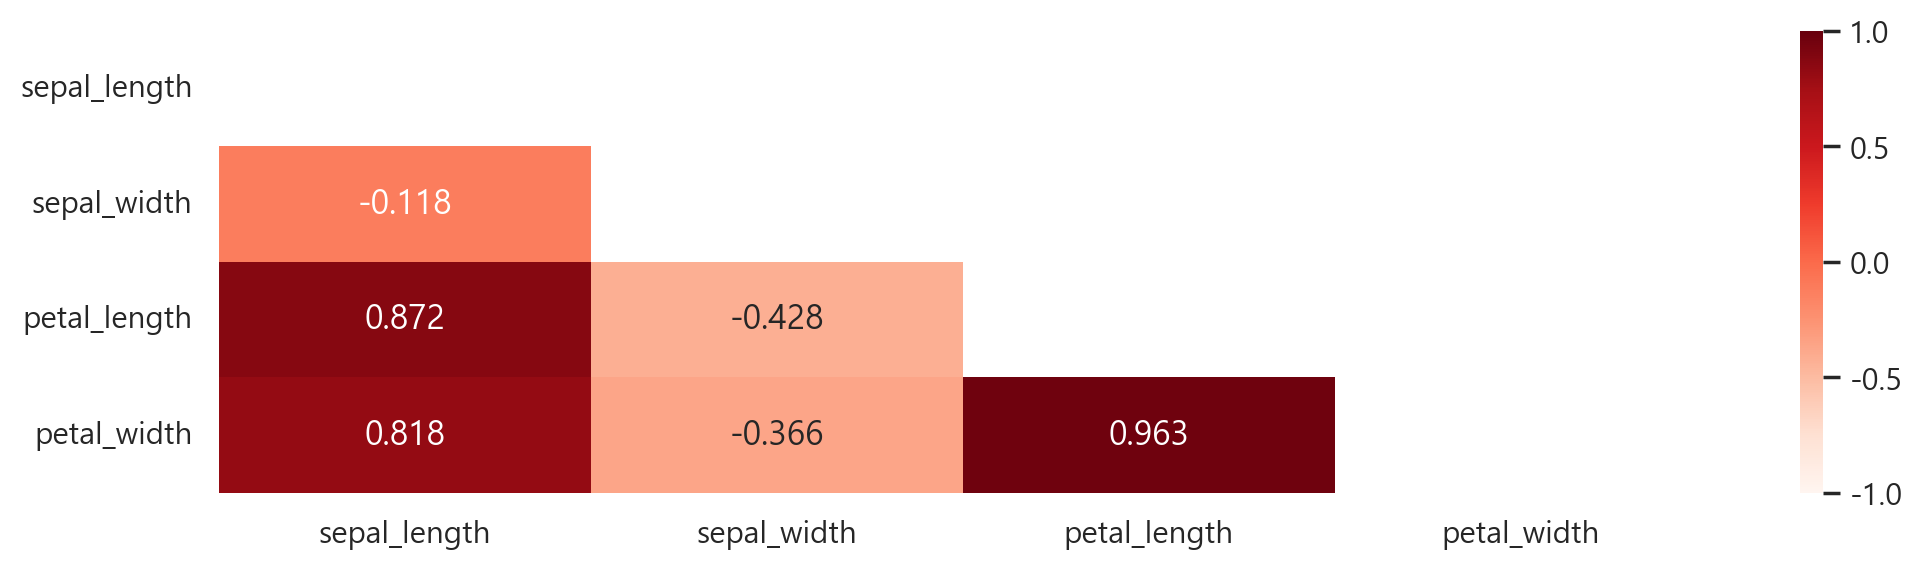

In [108]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,vmin=-1,vmax=1,annot=True,fmt='.3f',cmap='Reds',mask=mask)
plt.show()

https://seaborn.pydata.org/examples/many_pairwise_correlations.html(교안 83p)

In [112]:
np.ones((4,4),dtype='bool')

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [115]:
np.ones_like(corr,dtype='bool') #corr과 같은 shape의 배열(배열안 데이터 다 1)

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [117]:
# 행렬의 상삼각행렬
mask=np.triu(np.ones_like(corr,dtype='bool'))
mask

array([[ True,  True,  True,  True],
       [False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True]])

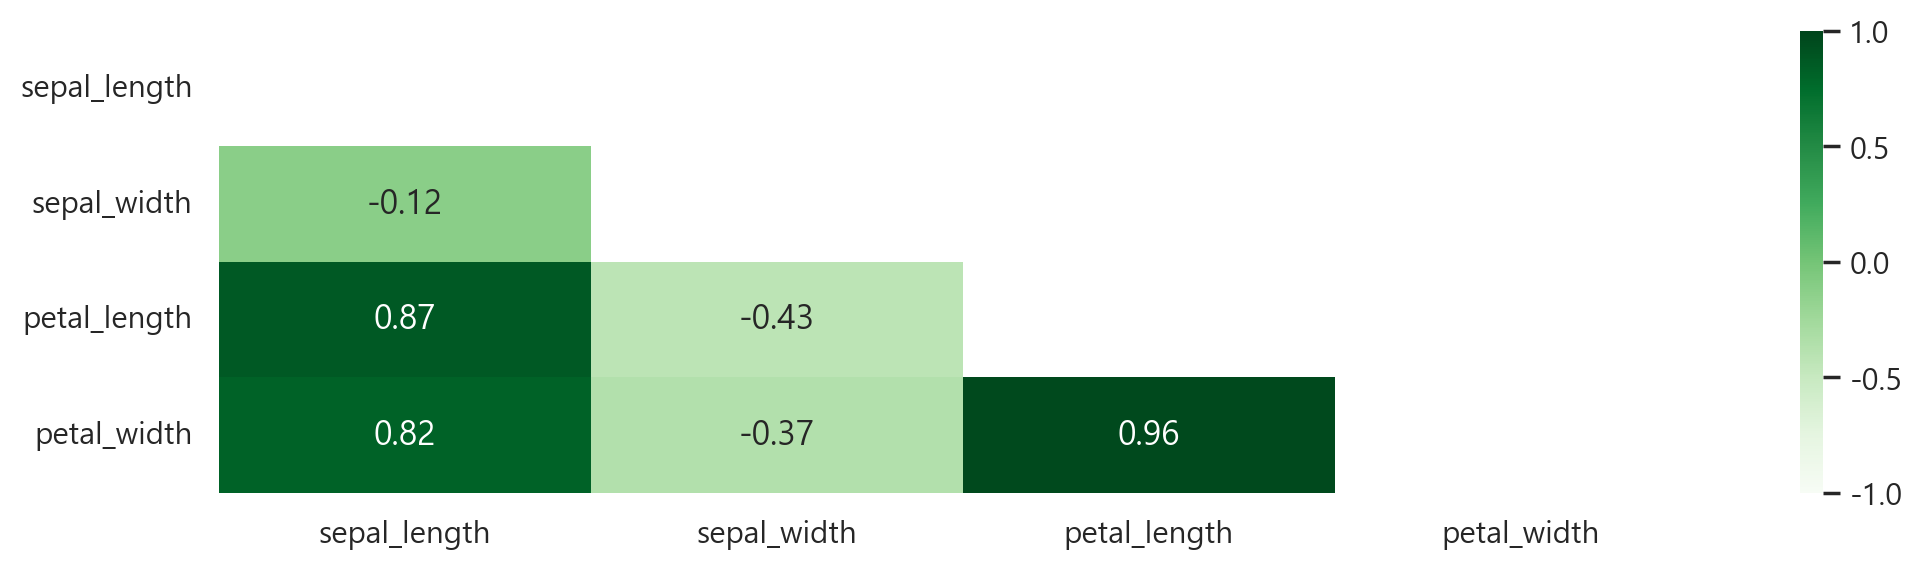

In [120]:
sns.heatmap(corr,vmin=-1,vmax=1,annot=True,cmap='Greens',mask=mask)
plt.show()

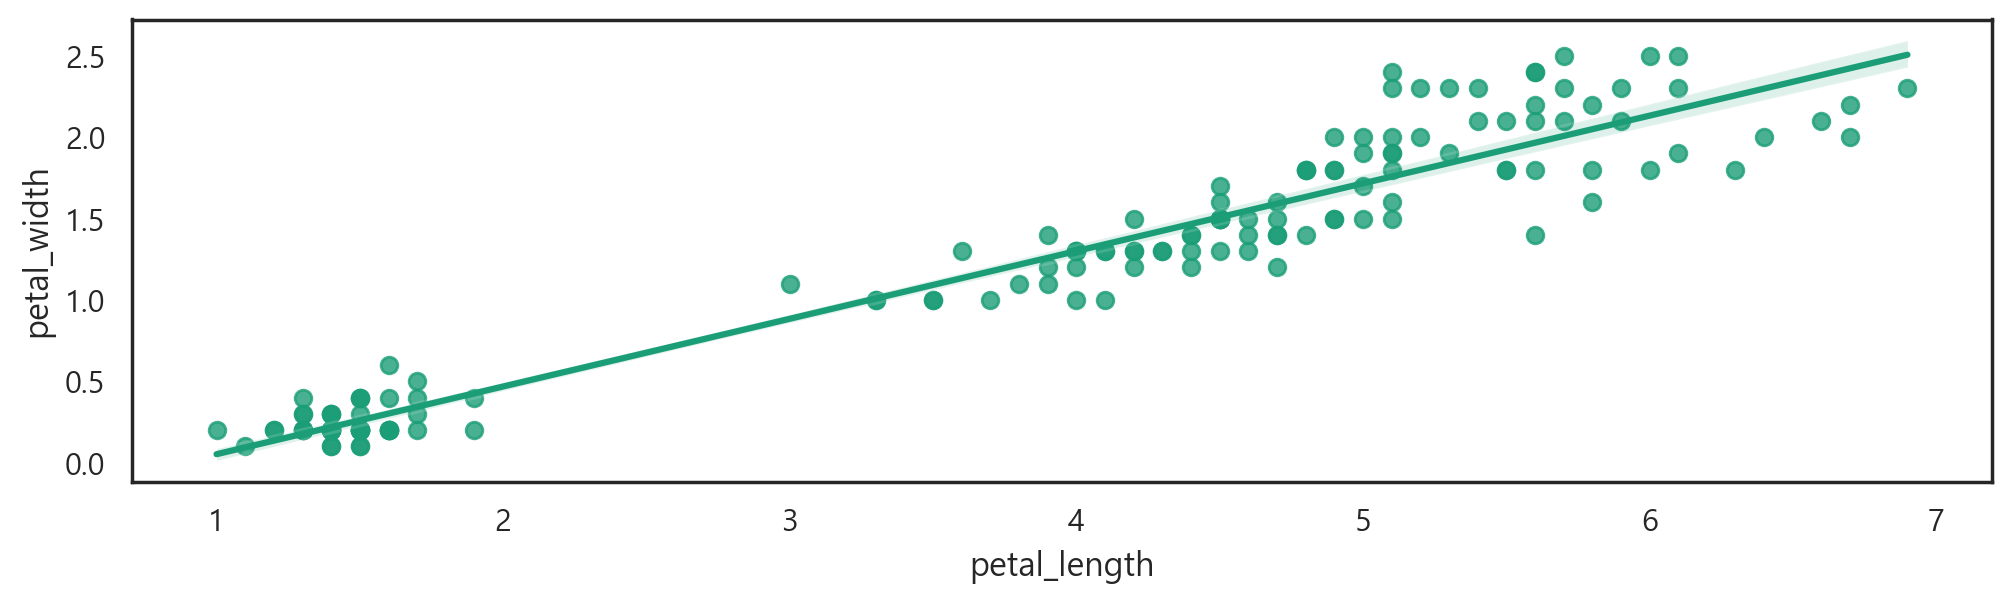

In [121]:
# 회귀그래프 : regplot(hue 사용불가),lmplot(hue사용가능)
sns.regplot(data=iris, x='petal_length',y='petal_width')
plt.show()

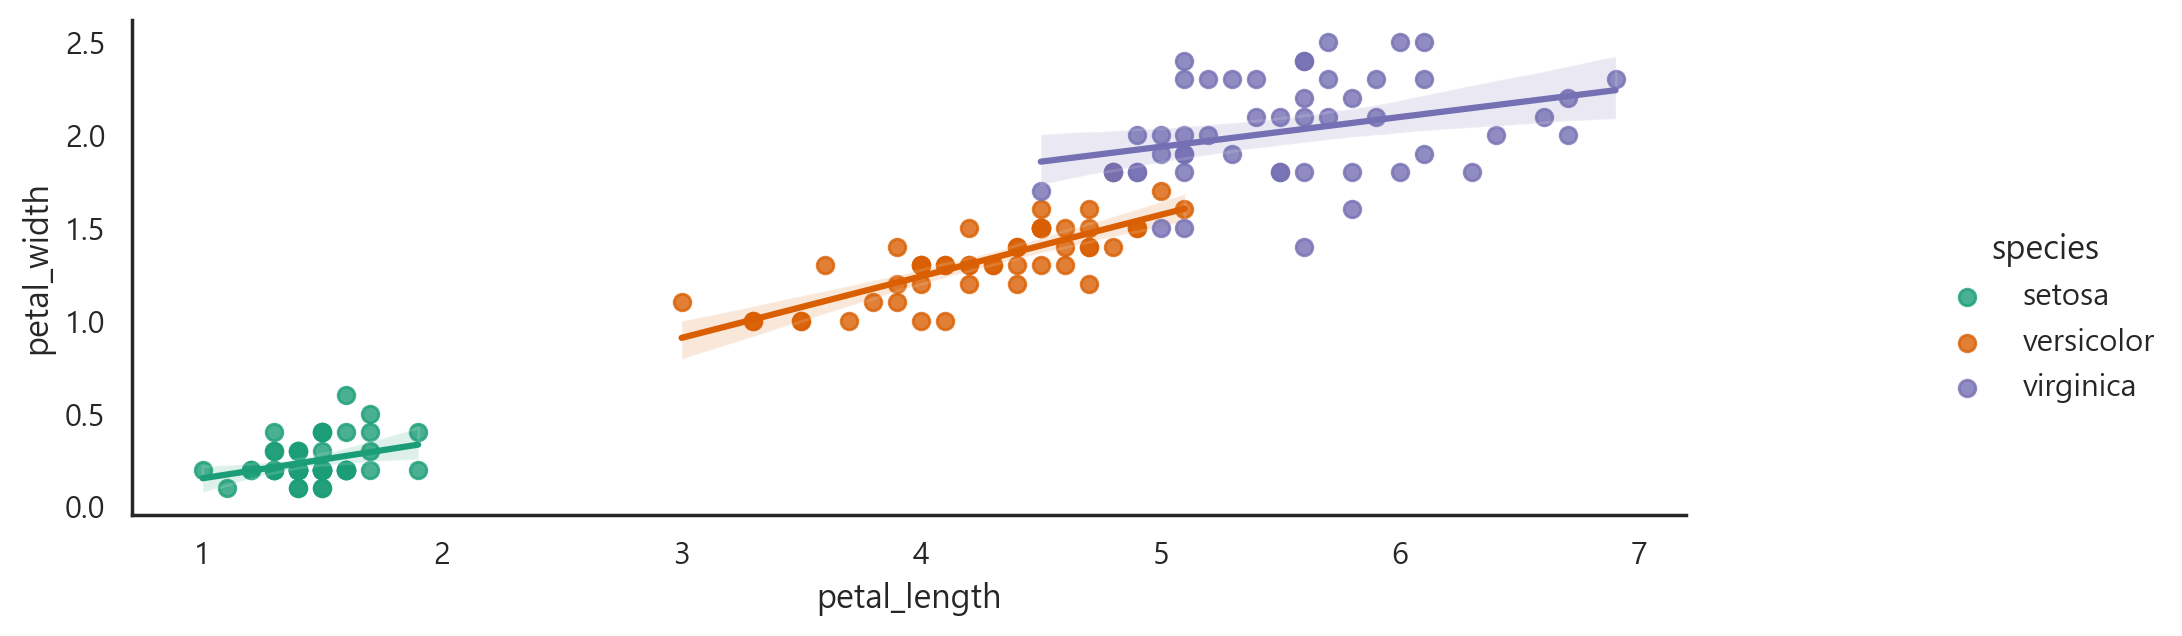

In [123]:
# species별 회귀그래프
g=sns.lmplot(data=iris, x='petal_length',y='petal_width',hue='species')
g.fig.set_size_inches(12,3)
plt.show()

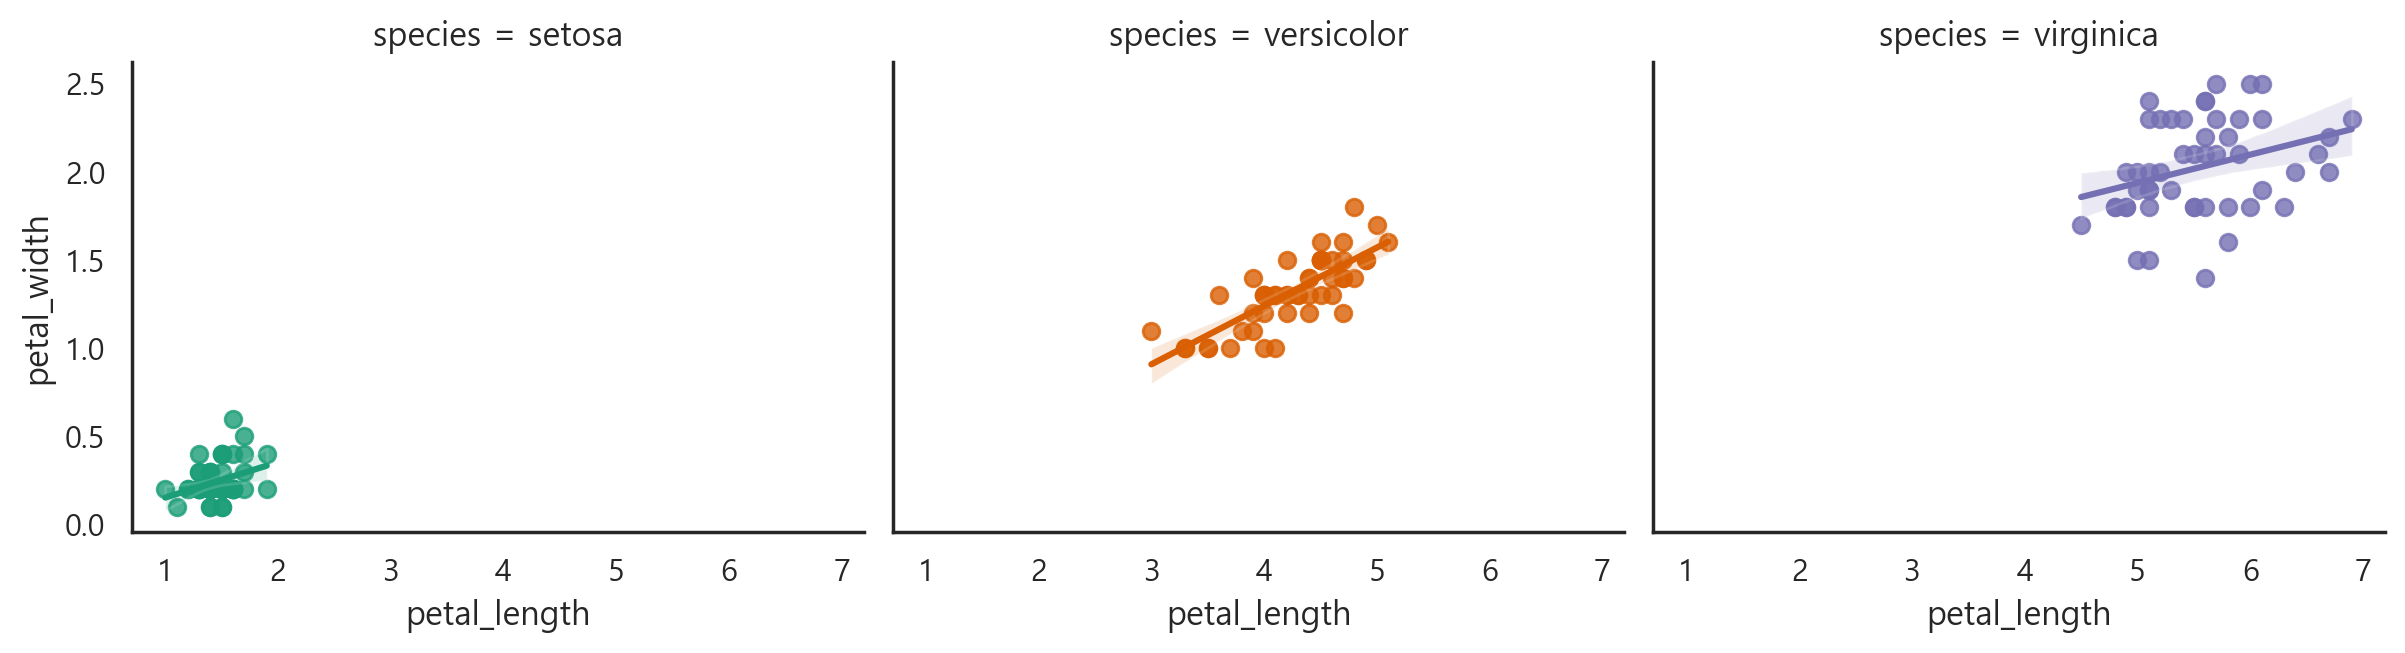

In [124]:
# species별 회귀그래프
g=sns.lmplot(data=iris, x='petal_length',y='petal_width',hue='species',
            col='species',
            #facet_kws=('sharey':False,'sharex':False) #축공유안함
            )
g.fig.set_size_inches(12,3)
plt.show()

## 2.4 다중그래프를 위한 FacetGrid

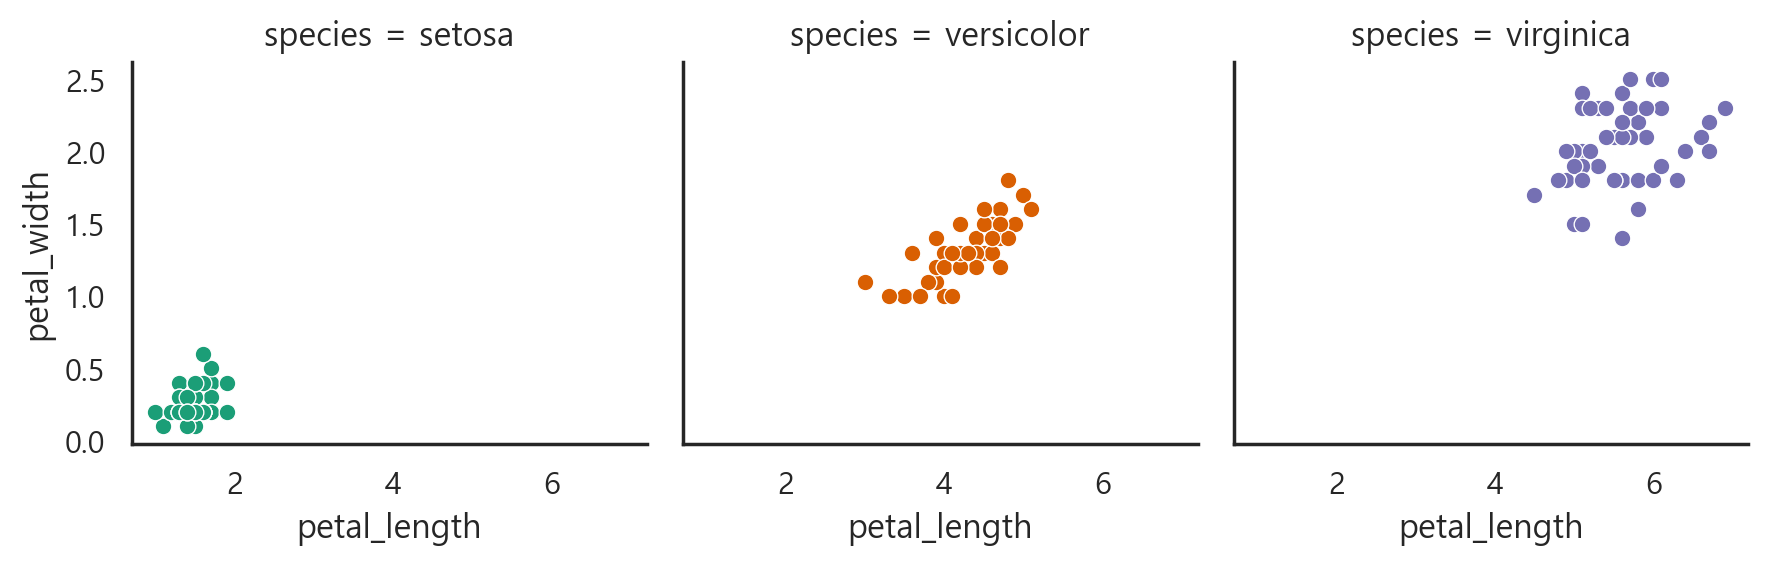

In [126]:
g = sns.FacetGrid(iris,col='species',hue='species')
g.map(sns.scatterplot,'petal_length','petal_width')
plt.show()

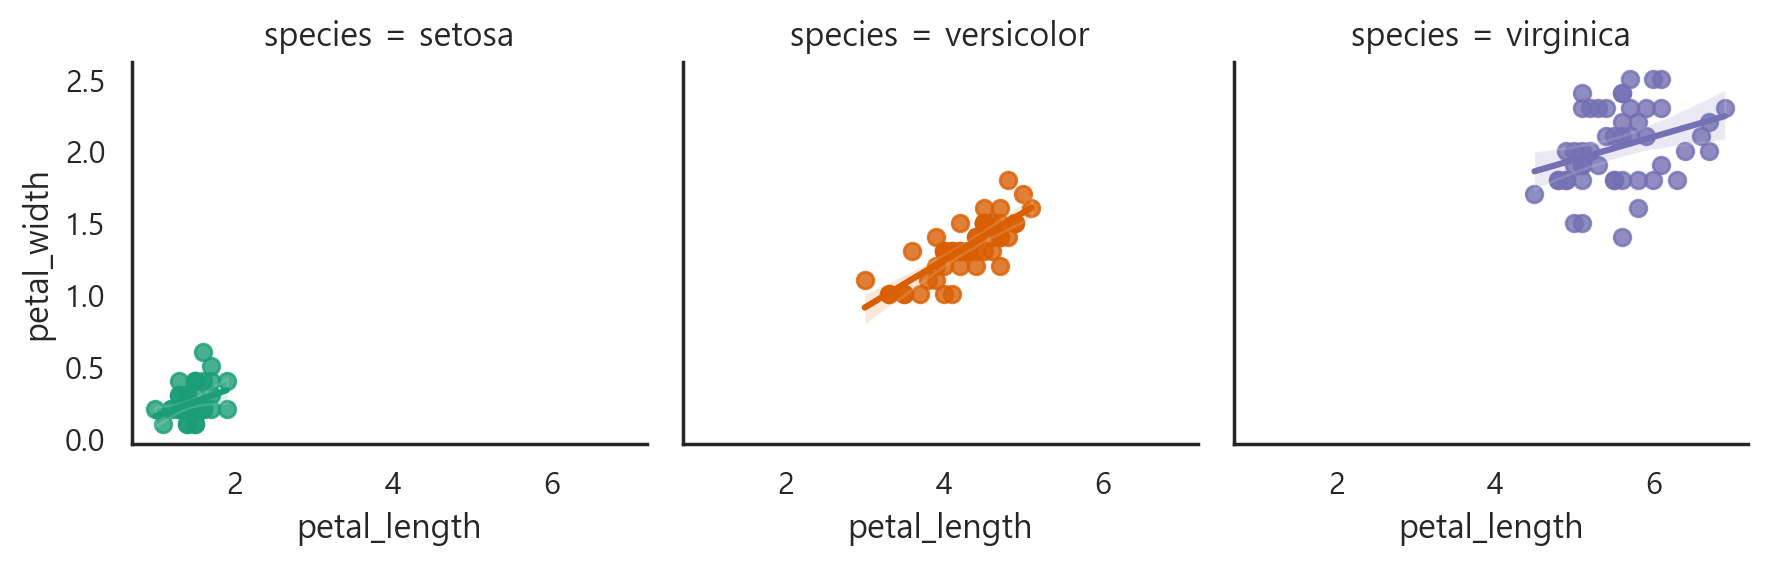

In [127]:
g = sns.FacetGrid(iris,col='species',hue='species')
g.map(sns.regplot,'petal_length','petal_width')
plt.show()

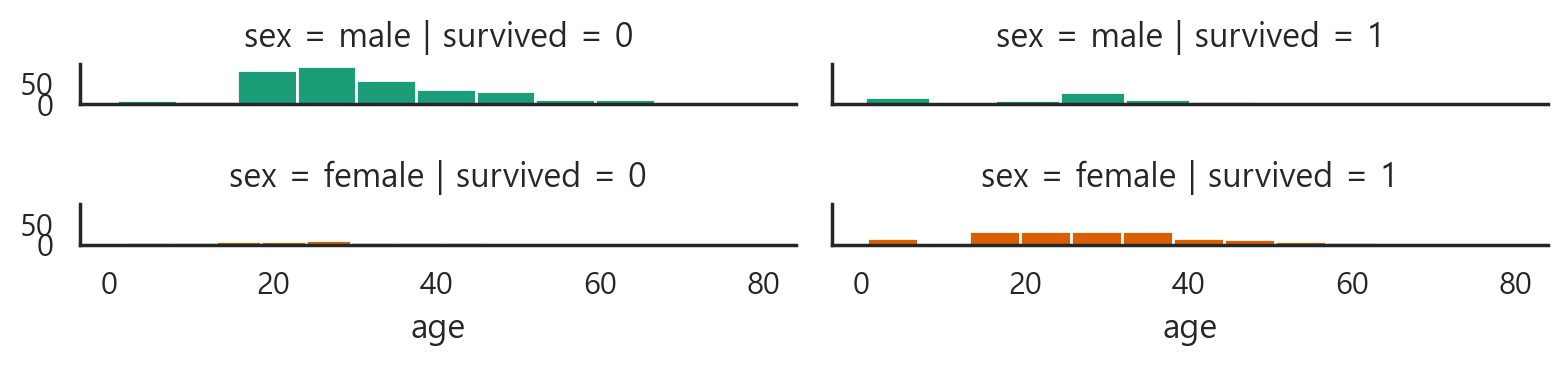

In [133]:
g = sns.FacetGrid(titanic,col='survived',hue='sex', row="sex")
g.map(plt.hist,'age')
g.fig.set_size_inches(8,2)
g.fig.tight_layout()# 서브플롯 간 자동으로 알맞게 배치
plt.show()